# Import

In [244]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import PrecisionRecallDisplay
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.contingency_tables import Table

# from imblearn.over_sampling import SMOTE


## Define columns

In [ ]:
# Определение типов признаков
numerical_features = [
    'buy_sell_ratio',
    'price_range',
    'buys_5min', # buys_cnt
    'sells_5min', # count_tx - buys_cnt
    'buy_perc_5min', # purchase percentage
    'sell_perc_5min', # sale-percentage
    'unique_buyers_5min', # unique buyers
    'unique_sellers_5min', # unique sellers
    'total_usd_volume_5min', # total eth_value
    'total_usd_buy_volume_5min', 
    'total_usd_sell_volume_5min', # sell_eth_value
    'jetton_creation_year', # creation-year
    'decimals', # decimals
    'avg_5min_lp_fee', # tax buy, tax sell
    'avg_5min_protocol_fee', # tax buy, tax sell
    'jetton_creation_trade_delta', # creation trade_delta
    'pool_creation_trade_delta', # creation pool delta
    'is_pool_creator', # is-pool creator
    'initial_tvl_usd', # Initial supply of tokens
    'initial_price', # initial price

    'initial_buy_price_5min', 
    'max_tvl_5min', 
    'min_tvl_5min',
    'buy_price_std_5min',
    'avg_buy_time_diff_5min',
    
    'initial_sell_price_5min',
    'sell_price_std_5min', 
    'price_max_5min', 
    'price_min_5min',
    'price_delta_5min',
    'avg_sell_time_diff_5min',

    'avg_time_diff_5min',
    'price_std_5min',

    'first_buy_time_ts',
    'first_sell_time_ts',
    'pool_deployment_at_ts',
    'jetton_deployment_at_ts',
    'min_pool_info_time_ts',
]
cyclical_features = [
    'pool_deployment_at_month', # creation month sin/cos
    'jetton_deployment_at_month' # creation month sin/cos
]

all_features = numerical_features + cyclical_features
print(all_features)

True


# Ston.fi

## Dataset load

In [381]:
stonfi_df = pd.read_csv('datasets/stonfi_dataset.csv')
stonfi_df['first_buy_time'] = pd.to_datetime(stonfi_df['first_buy_time'])
stonfi_df['first_buy_time_ts'] = stonfi_df['first_buy_time'].astype(np.int64) // 10**9
stonfi_df['first_sell_time'] = pd.to_datetime(stonfi_df['first_sell_time'])
stonfi_df['first_sell_time_ts'] = stonfi_df['first_sell_time'].astype(np.int64) // 10**9
stonfi_df['pool_deployment_at'] = pd.to_datetime(stonfi_df['pool_deployment_at'])
stonfi_df['pool_deployment_at_ts'] = stonfi_df['pool_deployment_at'].astype(np.int64) // 10**9
stonfi_df['jetton_deployment_at'] = pd.to_datetime(stonfi_df['jetton_deployment_at'])
stonfi_df['jetton_deployment_at_ts'] = stonfi_df['jetton_deployment_at'].astype(np.int64) // 10**9
stonfi_df['min_pool_info_time'] = pd.to_datetime(stonfi_df['min_pool_info_time'])
stonfi_df['min_pool_info_time_ts'] = stonfi_df['min_pool_info_time'].astype(np.int64) // 10**9
print(f'len of stonfi_df: {len(stonfi_df)}')
stonfi_df.head()

len of stonfi_df: 19717


,token_address,project,pool_address,version,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,...,max_tvl_360min,min_tvl_t_to_360min,tvl_420min,max_tvl_420min,min_tvl_t_to_420min,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts
0,0:936EB78BFD8739C74D0E91C145F2C3D0FAD3858CF885...,ston.fi,0:00482DFC070BEDFFCE1AF677134C6B57F7BC0C6FCAC8...,1,2024-04-04 13:50:49+00:00,0:9C4D5029DA0BF2571964C279C38EAC8B2BDEED16302F...,NOTDOGE,9.0,6.979443e-11,14,...,3407.120189,0.000000,0.000000,3407.120189,0.000000,1712239130,1712239412,1712238942,1712238649,1712238942
1,0:7CADF09EAFC052E297C058D061832F005DFBAD7A7AD7...,ston.fi,0:DA21E882DF41A3DE2D873EF5DE2525106364F9B56A6C...,1,2024-08-06 12:08:41+00:00,0:561FAB6954D3AE33A007594DD6A27E6E7B580A321C7F...,ZIO,9.0,2.946137e+05,8,...,16.909886,0.067879,0.067879,16.909886,0.067879,1722948423,1722949780,1722948349,1722946121,1722948349
2,0:FDD41F10B358BFA4DCC1A94F392E5D2E5C835BFC5232...,ston.fi,0:3115641DC329BB5CC82F43E52CEEF73A85C730E60B0A...,1,2024-08-26 09:05:50+00:00,0:63B7509C6DC4ACBD9FC3986C701AEE9473921064BFA0...,BHW,9.0,NaN,3,...,0.447500,0.225372,0.447500,0.447500,0.225372,1724679141,-9223372037,1724679084,1724663150,1724679084
3,0:2C8BDA106D17D938823D7946E6A49A5046C2CEB4A097...,ston.fi,0:FACBCA1E2C8335097FB16123EA188C8C42814FC25030...,2,2025-03-12 12:41:32+00:00,0:8612B00348795F2AFD77DD510E557F52A9EB6808CD43...,test123321,9.0,2.222266e-03,4,...,NaN,NaN,NaN,NaN,NaN,1741783779,1741784092,1741783733,1741783292,1742065839
4,0:60A9B61B241863C8C6D22BFB43E6320F7DEAF76F368D...,ston.fi,0:F379220A3F382FAD11B9CECE7FAA3558DEAEDCEC0A4C...,2,2024-11-27 15:50:05+00:00,0:DE9BE30612D71CDBF411D694255242366617AE241248...,LVT,9.0,1.487758e-06,9,...,25.272991,25.272991,25.272991,25.272991,25.272991,1732724132,-9223372037,1732723532,1732722605,1732723532


## Rug

### Alice

In [382]:
# # wrong approach
# x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
# y = [f"{i*100:.3}%" for i in [0.9757569609981235, 0.9753512197595983, 0.966069888928336, 0.9424354617842471, 0.8756403103920475, 0.7235887812547548]]
# pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

In [383]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
y = [f"{stonfi_df['alice_rugpull_' + i.replace(' ', '')].mean()*100:.3}%" for i in x]
print('Alice approach [Ston.Fi]')
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

Alice approach [Ston.Fi]


,time interval for rug,percent for rug
0,10 min,49.6%
1,30 min,68.7%
2,60 min,80.2%
3,120 min,87.6%
4,180 min,90.0%
5,240 min,91.4%
6,300 min,92.3%
7,360 min,93.0%
8,420 min,93.7%


### TVL

In [384]:
# # wrong approach
# x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
# y = [f"{i*100:.3}%" for i in [0.8226682100493002, 0.7281216676507285, 0.49012394645666385, 0.4225291757892659, 0.42095460815784086, 0.38911592746458806]]
# pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

In [385]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
y = [f"{((stonfi_df['max_tvl_' + i.replace(' ','')] - stonfi_df['min_tvl_t_to_' + i.replace(' ','')]) / stonfi_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() * 100:.3}%" for i in x]
print('TVL approach [Ston.Fi]')
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

TVL approach [Ston.Fi]


,time interval for rug,percent for rug
0,10 min,8.81%
1,30 min,20.3%
2,60 min,26.3%
3,120 min,30.1%
4,180 min,31.5%
5,240 min,32.3%
6,300 min,32.8%
7,360 min,33.2%
8,420 min,33.6%


In [386]:
print(f"{'column_name':27}, {'example':66}, {'null percent'}")
for c, i in zip(stonfi_df.columns, stonfi_df.iloc[0]):
    print(f"{c:27}= {str(i):66}, {stonfi_df[c].isna().mean()*100:.3}%")

column_name                , example                                                           , null percent
token_address              = 0:936EB78BFD8739C74D0E91C145F2C3D0FAD3858CF885288E24F02970ACE8155B, 0.0%
project                    = ston.fi                                                           , 0.0%
pool_address               = 0:00482DFC070BEDFFCE1AF677134C6B57F7BC0C6FCAC84028D78488C1194A819F, 0.0%
version                    = 1                                                                 , 0.0%
jetton_deployment_at       = 2024-04-04 13:50:49+00:00                                         , 0.0%
jetton_first_tx_sender     = 0:9C4D5029DA0BF2571964C279C38EAC8B2BDEED16302FC8099915439F9A3E929A, 0.0%
symbol                     = NOTDOGE                                                           , 0.538%
decimals                   = 9.0                                                               , 2.76%
buy_price_std_5min         = 6.979442536917667e-11                     

In [387]:
display(stonfi_df.describe(include='all'))

,token_address,project,pool_address,version,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,...,max_tvl_360min,min_tvl_t_to_360min,tvl_420min,max_tvl_420min,min_tvl_t_to_420min,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts
count,19717,19717,19717,19717.000000,19717,19717,19611,19173.000000,1.120300e+04,19717.000000,...,1.771600e+04,1.702000e+04,1.774300e+04,1.774300e+04,1.702000e+04,1.971700e+04,1.971700e+04,1.971700e+04,1.971700e+04,1.971700e+04
unique,19516,1,19717,NaN,NaN,12943,13053,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:2F956143C461769579BAEF2E32CC2D7BC18283F40D20...,ston.fi,0:033754612381ECB378DBA8D3BDEAC41DECB116A12DAC...,NaN,NaN,0:BDDF242D6C6B565AFC04AE709586257A511304D75A8E...,USDT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,19717,1,NaN,NaN,685,197,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.289091,2024-07-15 09:42:09.189430272+00:00,NaN,NaN,8.550253,2.206642e+07,442.486839,...,6.372743e+03,3.210557e+03,4.099408e+03,6.427952e+03,3.172926e+03,1.542864e+09,-2.215933e+09,1.090531e+09,1.721037e+09,1.090586e+09
min,NaN,NaN,NaN,1.000000,2022-06-05 21:18:30+00:00,NaN,NaN,0.000000,0.000000e+00,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.223372e+09,-9.223372e+09,-9.223372e+09,1.654464e+09,-9.223372e+09
25%,NaN,NaN,NaN,1.000000,2024-04-14 11:17:11+00:00,NaN,NaN,9.000000,9.324799e-08,2.000000,...,1.522781e+00,1.300000e-05,1.600000e-05,1.569409e+00,1.300000e-05,1.713079e+09,-9.223372e+09,1.711898e+09,1.713093e+09,1.711899e+09
50%,NaN,NaN,NaN,1.000000,2024-06-06 13:09:19+00:00,NaN,NaN,9.000000,4.789602e-06,4.000000,...,1.016614e+02,2.654670e-01,3.374090e-01,1.022212e+02,2.582585e-01,1.717873e+09,1.711469e+09,1.716649e+09,1.717679e+09,1.716651e+09
75%,NaN,NaN,NaN,2.000000,2024-11-06 13:52:28+00:00,NaN,NaN,9.000000,2.551662e+00,15.000000,...,2.304043e+03,2.324692e+01,3.503210e+01,2.304796e+03,2.189667e+01,1.731925e+09,1.719303e+09,1.726500e+09,1.730901e+09,1.726517e+09
max,NaN,NaN,NaN,2.000000,2025-03-31 20:33:15+00:00,NaN,NaN,33.000000,4.478343e+10,848932.000000,...,8.020130e+06,6.279479e+06,6.576678e+06,8.020130e+06,6.279479e+06,1.743454e+09,1.743459e+09,1.743454e+09,1.743453e+09,1.747672e+09


## Drop some tokens

In [388]:
for token in ['0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F', '0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C', '0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000', '0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE']:
    tmp = stonfi_df[stonfi_df['token_address'] == token]['symbol'] # STON
    print(f"Drop token {token}: {tmp.iloc[0]}, len = {len(tmp)}")
    stonfi_df = stonfi_df[stonfi_df['token_address'] != token]

Drop token 0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F: STON, len = 3
Drop token 0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C: STORM, len = 1
Drop token 0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000: tsTON, len = 1
Drop token 0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE: USD₮, len = 4


In [389]:
# дропаем токены без данных
print(f'len of stonfi_df: {len(stonfi_df)}')
stonfi_df = stonfi_df[stonfi_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1).isna() == False]
# stonfi_df = stonfi_df[stonfi_df['max_tvl_5min'].isna() == False]
print(f'len of stonfi_df after drop: {len(stonfi_df)}')

len of stonfi_df: 19708
len of stonfi_df after drop: 19386


## Define target

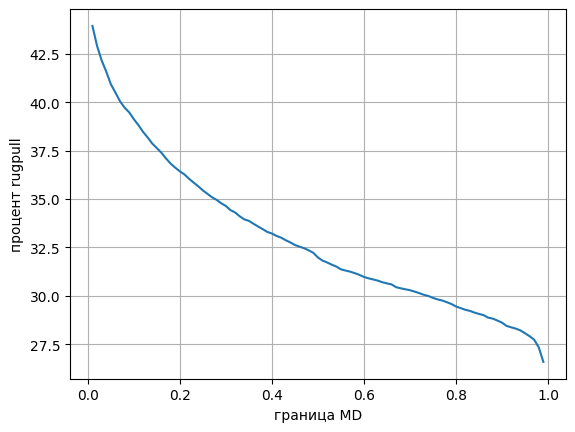

In [390]:
plt.plot([i/100 for i in range(1,100)], [(((stonfi_df['max_tvl_60min'] - stonfi_df['min_tvl_t_to_60min']) / stonfi_df['max_tvl_60min'] > i / 100).astype(int)).mean()*100 for i in range(1,100)])
plt.grid()
plt.xlabel('граница MD')
plt.ylabel('процент rugpull')
plt.show()

In [391]:
# определяем таргет
# stonfi_df['target'] = stonfi_df['alice_rugpull_180min']
stonfi_df['tvl_target_10min'] = ((stonfi_df['max_tvl_10min'] -   stonfi_df['min_tvl_t_to_10min']) / stonfi_df['max_tvl_10min'] > 0.99).astype(int)
stonfi_df['tvl_target_30min'] = ((stonfi_df['max_tvl_30min'] -   stonfi_df['min_tvl_t_to_30min']) / stonfi_df['max_tvl_30min'] > 0.99).astype(int)
stonfi_df['tvl_target_60min'] = ((stonfi_df['max_tvl_60min'] -   stonfi_df['min_tvl_t_to_60min']) / stonfi_df['max_tvl_60min'] > 0.99).astype(int)
stonfi_df['tvl_target_120min'] = ((stonfi_df['max_tvl_120min'] - stonfi_df['min_tvl_t_to_120min']) / stonfi_df['max_tvl_120min'] > 0.99).astype(int)
stonfi_df['tvl_target_180min'] = ((stonfi_df['max_tvl_180min'] - stonfi_df['min_tvl_t_to_180min']) / stonfi_df['max_tvl_180min'] > 0.99).astype(int)
stonfi_df['tvl_target_240min'] = ((stonfi_df['max_tvl_240min'] - stonfi_df['min_tvl_t_to_240min']) / stonfi_df['max_tvl_240min'] > 0.99).astype(int)
stonfi_df['tvl_target_300min'] = ((stonfi_df['max_tvl_300min'] - stonfi_df['min_tvl_t_to_300min']) / stonfi_df['max_tvl_300min'] > 0.99).astype(int)
stonfi_df['tvl_target_360min'] = ((stonfi_df['max_tvl_360min'] - stonfi_df['min_tvl_t_to_360min']) / stonfi_df['max_tvl_360min'] > 0.99).astype(int)
stonfi_df['tvl_target_420min'] = ((stonfi_df['max_tvl_420min'] - stonfi_df['min_tvl_t_to_420min']) / stonfi_df['max_tvl_420min'] > 0.99).astype(int)
stonfi_df = stonfi_df.drop(['max_tvl_10min', 'max_tvl_30min', 'max_tvl_60min', 'max_tvl_120min', 'max_tvl_180min', 'max_tvl_240min', 'max_tvl_300min', 'max_tvl_360min', 'max_tvl_420min', 'min_tvl_t_to_10min', 'min_tvl_t_to_30min', 'min_tvl_t_to_60min', 'min_tvl_t_to_120min', 'min_tvl_t_to_180min', 'min_tvl_t_to_240min', 'min_tvl_t_to_300min', 'min_tvl_t_to_360min', 'min_tvl_t_to_420min'], axis=1) 
print(f"tvl_target_60min = {float(stonfi_df['tvl_target_60min'].sum()/len(stonfi_df)) * 100:.3}% rugpulls")
print(f'len of stonfi_df: {len(stonfi_df)}')

tvl_target_60min = 26.6% rugpulls
len of stonfi_df: 19386


In [392]:
# stonfi_df = stonfi_df.drop(['alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
#        'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
#        'alice_rugpull_420min'], axis=1)
print(stonfi_df.columns)

Index(['token_address', 'project', 'pool_address', 'version',
       'jetton_deployment_at', 'jetton_first_tx_sender', 'symbol', 'decimals',
       'buy_price_std_5min', 'buys_cnt', 'buys_5min', 'avg_buy_time_diff_5min',
       'total_usd_buy_volume', 'total_usd_buy_volume_5min', 'unique_buyers',
       'unique_buyers_5min', 'first_buy_time', 'initial_buy_price',
       'initial_buy_price_5min', 'sell_price_std_5min', 'sells_cnt',
       'sells_5min', 'avg_sell_time_diff_5min', 'total_usd_sell_volume',
       'total_usd_sell_volume_5min', 'unique_sellers', 'unique_sellers_5min',
       'first_sell_time', 'initial_sell_price', 'initial_sell_price_5min',
       'avg_time_diff_5min', 'initial_price', 'price_5min', 'price_std_5min',
       'price_max_5min', 'price_min_5min', 'price_max_hour', 'price_min_hour',
       'alice_rugpull_10min', 'alice_rugpull_30min', 'alice_rugpull_60min',
       'alice_rugpull_120min', 'alice_rugpull_180min', 'alice_rugpull_240min',
       'alice_rugpull_300mi

In [393]:
print(f"{'column_name':27}, {'example':66}, {'null percent'}")
for c, i in zip(stonfi_df.columns, stonfi_df.iloc[0]):
    print(f"{c:27}= {str(i):66}, {stonfi_df[c].isna().mean()*100:.3}%")

column_name                , example                                                           , null percent
token_address              = 0:936EB78BFD8739C74D0E91C145F2C3D0FAD3858CF885288E24F02970ACE8155B, 0.0%
project                    = ston.fi                                                           , 0.0%
pool_address               = 0:00482DFC070BEDFFCE1AF677134C6B57F7BC0C6FCAC84028D78488C1194A819F, 0.0%
version                    = 1                                                                 , 0.0%
jetton_deployment_at       = 2024-04-04 13:50:49+00:00                                         , 0.0%
jetton_first_tx_sender     = 0:9C4D5029DA0BF2571964C279C38EAC8B2BDEED16302FC8099915439F9A3E929A, 0.0%
symbol                     = NOTDOGE                                                           , 0.516%
decimals                   = 9.0                                                               , 2.7%
buy_price_std_5min         = 6.979442536917667e-11                      

## Dataset prepare

In [394]:
stonfi_df['first_trade_time'] = stonfi_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
stonfi_df['count_tx_5min'] = stonfi_df['buys_5min'] + stonfi_df['sells_5min']
stonfi_df['buy_perc_5min'] = stonfi_df['buys_5min']/stonfi_df['count_tx_5min']
stonfi_df['sell_perc_5min'] = stonfi_df['sells_5min']/stonfi_df['count_tx_5min']
stonfi_df['total_usd_volume_5min'] = stonfi_df['total_usd_buy_volume_5min'] + stonfi_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    stonfi_df[f'{col}_month'] = pd.to_datetime(stonfi_df[col]).dt.month
stonfi_df['jetton_creation_year'] = pd.to_datetime(stonfi_df['jetton_deployment_at']).dt.year
stonfi_df['jetton_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['jetton_deployment_at']).dt.seconds
stonfi_df['pool_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['pool_deployment_at']).dt.seconds
stonfi_df['is_pool_creator'] = (stonfi_df['pool_first_tx_sender'] == stonfi_df['jetton_first_tx_sender']).astype(int)

stonfi_df['buy_sell_ratio'] = stonfi_df['buys_5min'] / (stonfi_df['sells_5min'] + 1e-6)
stonfi_df['price_range'] = stonfi_df['price_max_5min'] - stonfi_df['price_min_5min']
stonfi_df['price_delta_5min'] = stonfi_df['price_5min'] - stonfi_df['initial_price']

## Correlation analysis

In [395]:
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']

In [434]:
def plot_features(df, numerical_features, cyclical_features):
    # --- Гистограммы для числовых признаков ---
    num_plots = len(numerical_features)
    cols = 4
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(numerical_features):
        ax = axes[i]
        ax.hist(df[feature], bins=30, color='skyblue', edgecolor='black')
        ax.set_title(feature)
        ax.grid(True, linestyle='--', alpha=0.5)

    # Удаляем лишние пустые оси
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # --- Гистограммы для циклических признаков (например, месяц) ---
    fig, axes = plt.subplots(1, len(cyclical_features), figsize=(12, 5))

    if len(cyclical_features) == 1:
        axes = [axes]

    for i, feature in enumerate(cyclical_features):
        axes[i].hist(df[feature], bins=12, color='lightgreen', edgecolor='black', rwidth=0.8)
        axes[i].set_title(f'Гистограмма {feature}')
        axes[i].set_xlabel('Месяц')
        axes[i].set_ylabel('Частота')
        axes[i].set_xticks(range(1, 13))
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


C:\Users\Димас\AppData\Local\Temp\ipykernel_21332\947630115.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k-1, r-1))
C:\Users\Димас\AppData\Local\Temp\ipykernel_21332\947630115.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


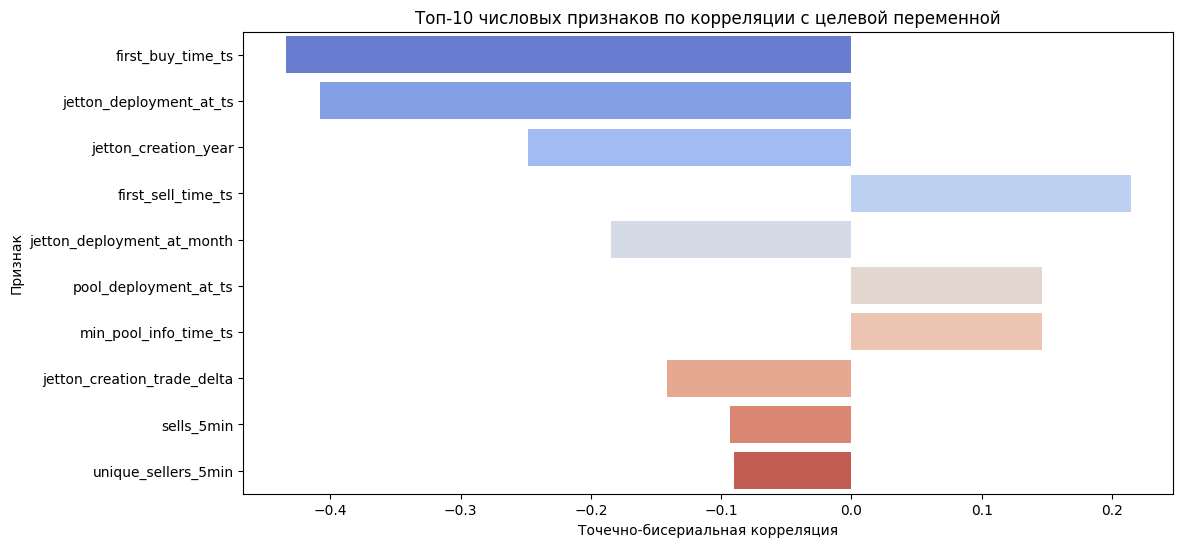

Топ числовых признаков:
                    feature  correlation       p-value
          first_buy_time_ts    -0.434473  0.000000e+00
    jetton_deployment_at_ts    -0.407710  0.000000e+00
       jetton_creation_year    -0.248324 2.864185e-270
         first_sell_time_ts     0.214687 6.441942e-201
 jetton_deployment_at_month    -0.184510 4.993639e-148
      pool_deployment_at_ts     0.146224  4.152055e-93
      min_pool_info_time_ts     0.146210  4.320432e-93
jetton_creation_trade_delta    -0.141946  8.512083e-88
                 sells_5min    -0.093167  1.232355e-38
        unique_sellers_5min    -0.090505  1.510279e-36

Топ категориальных признаков:
               feature  cramers_v
          pool_address   1.000000
         token_address   0.999052
jetton_first_tx_sender   0.913867
                symbol   0.856391
  pool_first_tx_sender   0.853433
               project        NaN


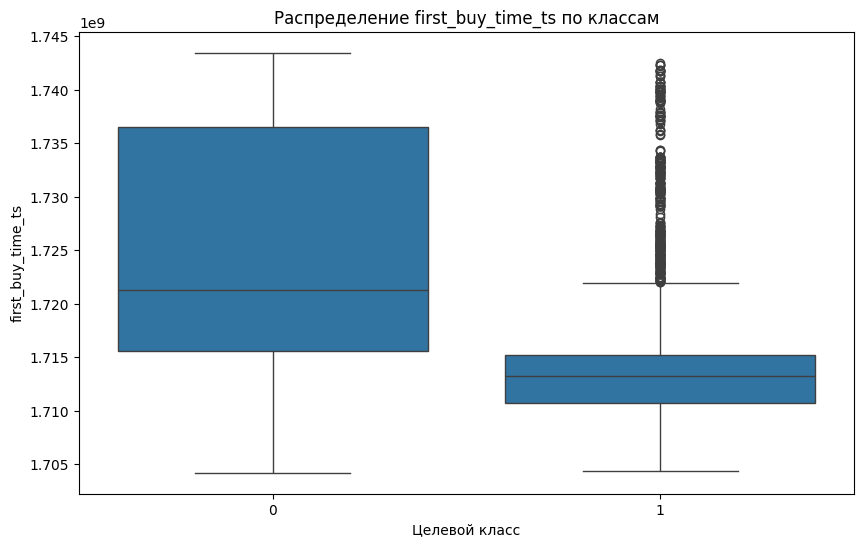

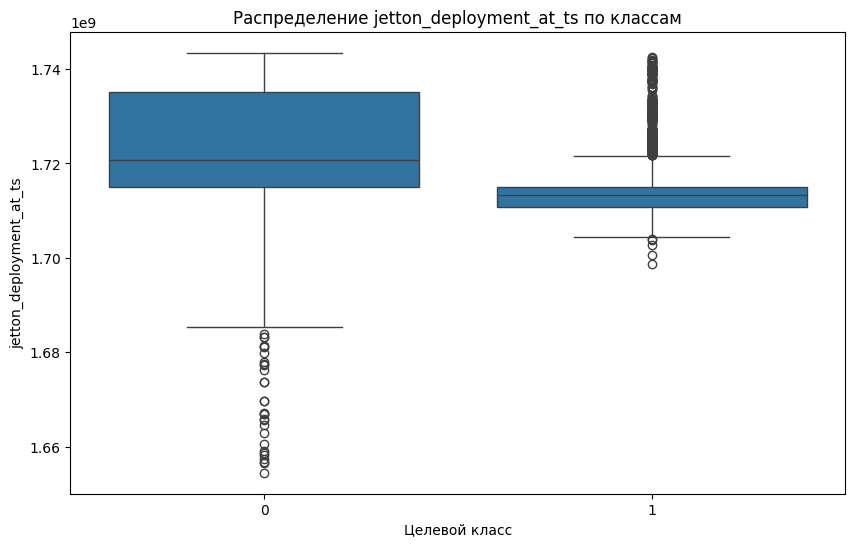

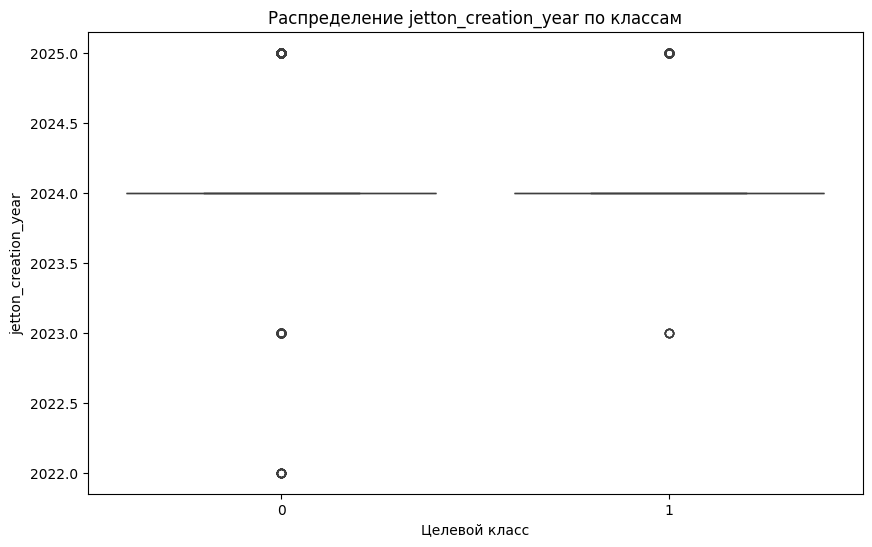

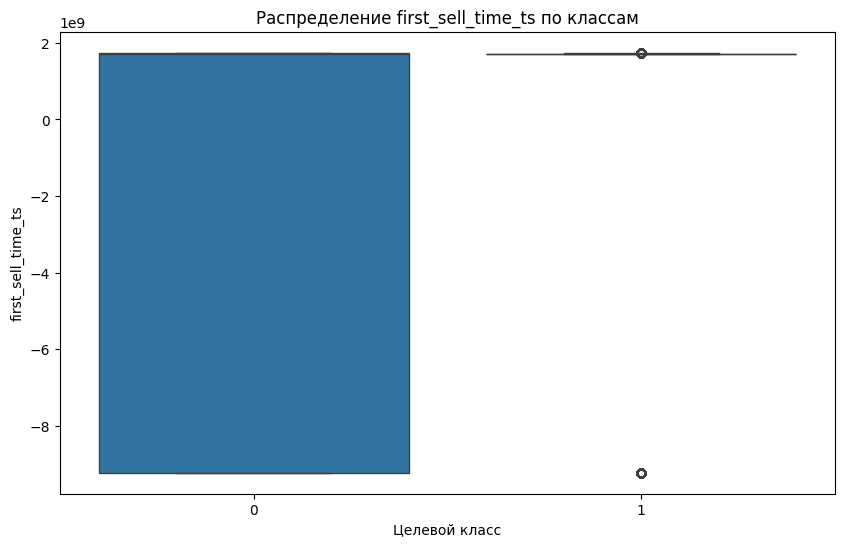

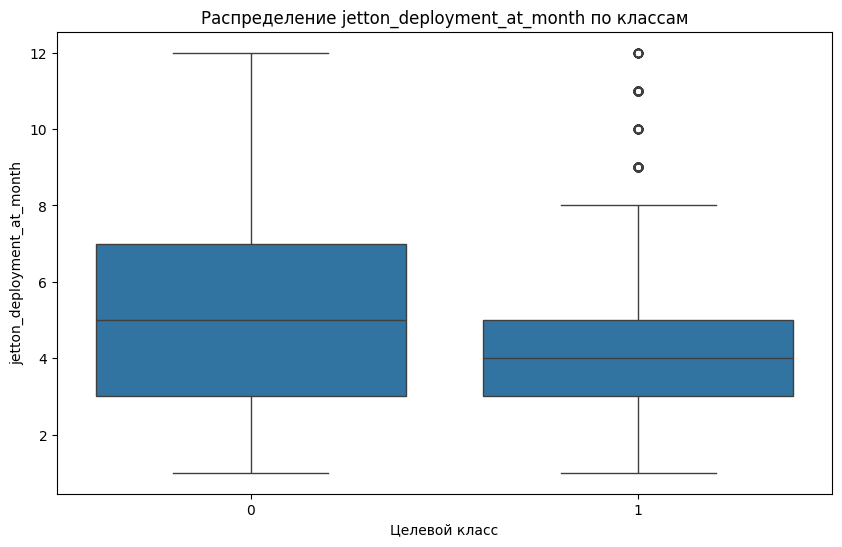

In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.contingency_tables import Table

def cramers_v(x, y):
    """Вычисление корреляции Крамера для категориальных признаков"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Анализ для числовых признаков
numeric_features = stonfi_df[numerical_features + cyclical_features].select_dtypes(include=np.number).columns.tolist()
# numeric_features.remove('target')  # Исключаем целевую переменную

numeric_correlations = []
for feature in numeric_features:
    r, p = pointbiserialr(stonfi_df[feature], stonfi_df['target'])
    numeric_correlations.append({
        'feature': feature,
        'correlation': r,
        'p-value': p
    })
    
numeric_corr_df = pd.DataFrame(numeric_correlations).sort_values(
    by='correlation', key=abs, ascending=False)

# Анализ для категориальных признаков
categorical_features = stonfi_df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_correlations = []
for feature in categorical_features:
    v = cramers_v(stonfi_df[feature], stonfi_df['target'])
    categorical_correlations.append({
        'feature': feature,
        'cramers_v': v
    })
    
categorical_corr_df = pd.DataFrame(categorical_correlations).sort_values(
    by='cramers_v', ascending=False)

# Визуализация результатов
plt.figure(figsize=(12, 6))
sns.barplot(
    x='correlation', 
    y='feature', 
    data=numeric_corr_df.head(10),
    palette='coolwarm'
)
plt.title('Топ-10 числовых признаков по корреляции с целевой переменной')
plt.xlabel('Точечно-бисериальная корреляция')
plt.ylabel('Признак')
plt.show()

# Вывод результатов
print("Топ числовых признаков:")
print(numeric_corr_df.head(10).to_string(index=False))

print("\nТоп категориальных признаков:")
print(categorical_corr_df.head(10).to_string(index=False))

# Пример визуализации распределения для топ-признака
top_n = 5
for i in range(top_n):
    top_feature = numeric_corr_df.iloc[i]['feature']
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='target', y=top_feature, data=stonfi_df)
    plt.title(f'Распределение {top_feature} по классам')
    plt.xlabel('Целевой класс')
    plt.ylabel(top_feature)
    plt.show()


# Dedust

## Dataset load

In [408]:
dedust_df = pd.read_csv('datasets/dedust_dataset.csv')
# обучаемся только на дедасте
dedust_df = dedust_df[dedust_df['project'] == 'dedust']

dedust_df['first_buy_time'] = pd.to_datetime(dedust_df['first_buy_time'])
dedust_df['first_buy_time_ts'] = dedust_df['first_buy_time'].astype(np.int64) // 10**9
dedust_df['first_sell_time'] = pd.to_datetime(dedust_df['first_sell_time'])
dedust_df['first_sell_time_ts'] = dedust_df['first_sell_time'].astype(np.int64) // 10**9
dedust_df['pool_deployment_at'] = pd.to_datetime(dedust_df['pool_deployment_at'])
dedust_df['pool_deployment_at_ts'] = dedust_df['pool_deployment_at'].astype(np.int64) // 10**9
dedust_df['jetton_deployment_at'] = pd.to_datetime(dedust_df['jetton_deployment_at'])
dedust_df['jetton_deployment_at_ts'] = dedust_df['jetton_deployment_at'].astype(np.int64) // 10**9
dedust_df['min_pool_info_time'] = pd.to_datetime(dedust_df['min_pool_info_time'])
dedust_df['min_pool_info_time_ts'] = dedust_df['min_pool_info_time'].astype(np.int64) // 10**9
print(f'len of dedust_df: {len(dedust_df)}')
dedust_df.head()

len of dedust_df: 33087


,token_address,project,pool_address,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,buys_5min,...,max_tvl_360min,min_tvl_t_to_360min,tvl_420min,max_tvl_420min,min_tvl_t_to_420min,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts
0,0:16590A541EF9DCBF226EAAD35BF7264B64F8DF0D8183...,dedust,0:DF28494AE0F7FB95B0135B483B8F035F0D2E31984B61...,2024-04-19 06:08:58+00:00,0:58E9F5E1E8A4A85F3C6C72062702274AAD5E66487E7B...,NOOB,9.0,NaN,3,1,...,1707.151582,0.000000,0.000000,1707.151582,0.000000,1713507319,-9223372037,1713507178,1713506938,1713507221
1,0:A1B6B9535FB0AB9F6A0DCBAAD9695E7AC9B5C51E6DF9...,dedust,0:896620C616C625A798974854E9CC4E711CC3E216F5F4...,2024-03-15 13:19:56+00:00,0:BAC5A4969AFD52136ADDDAD30BA7A1A835851191E4FB...,Exodus,9.0,2.834540e-06,28,2,...,2229.276182,0.000000,0.000000,2229.276182,0.000000,1710509116,1710509725,1710508995,1710508796,1710509116
2,0:D2AABF09AE3D70D428D74D58E54044E18F844ED156FA...,dedust,0:CD3D1CEA851D0F92837A61C3CA3F328BF9DE30E544CB...,2024-01-07 12:40:10+00:00,0:F654FA8A010277977ACBE659B87A7EE3AD383D3849EE...,DOGETON,9.0,3.907499e-09,14,8,...,970.541935,0.000000,0.000000,970.541935,0.000000,1704631442,1704631821,1704631407,1704631210,1704631442
3,0:9FA27322066E00DCBBA9B0A150BD42137FAFB2AF235A...,dedust,0:B488B4B98E95AD65AC9246668A0B19381611711F201C...,2024-07-21 20:41:52+00:00,0:135F1D9C515AD0DB5BE0299541DE254305E850AF9AA9...,POKEMON,9.0,3.480383e-05,15,7,...,19898.626851,0.142231,0.142231,19898.626851,0.142231,1721594842,1721595782,1721594644,1721594512,1721594903
4,0:A6AC3C322843A3730AAA9F16A15DEFA032A21D0FB41B...,dedust,0:816BDF76FCA9AC29F8C80AE91DCEFAB6AB31F4A6F826...,2024-07-14 11:20:53+00:00,0:BC0D8E3162C4A1D4BE14B4EBFF6A809FE2963D21A56E...,DRAGON,NaN,3.011711e-07,453,51,...,14979.366121,5870.770352,5903.869230,14979.366121,5870.770352,1720956376,1720956427,1720956279,1720956053,1720956463


## Rug

### Alice

In [369]:
# # wrong approach
# x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
# y = [f"{i*100:.3}%" for i in [0.9757569609981235, 0.9753512197595983, 0.966069888928336, 0.9424354617842471, 0.8756403103920475, 0.7235887812547548]]
# pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

In [409]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
y = [f"{dedust_df['alice_rugpull_' + i.replace(' ', '')].mean()*100:.3}%" for i in x]
print('Alice approach [Dedust]')
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

Alice approach [Dedust]


,time interval for rug,percent for rug
0,10 min,38.3%
1,30 min,65.9%
2,60 min,80.4%
3,120 min,89.4%
4,180 min,92.1%
5,240 min,93.5%
6,300 min,94.4%
7,360 min,95.1%
8,420 min,95.6%


### TVL

In [371]:
# # wrong approach
# x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
# y = [f"{i*100:.3}%" for i in [0.9265339720519788, 0.9141651365165896, 0.6365865004039596, 0.6324095851321098, 0.6313477017825908, 0.613540944095797]]
# pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

In [410]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
y = [f"{((dedust_df['max_tvl_' + i.replace(' ','')] - dedust_df['min_tvl_t_to_' + i.replace(' ','')]) / dedust_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() * 100:.3}%" for i in x]
print('TVL approach [Ston.Fi]')
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

TVL approach [Ston.Fi]


,time interval for rug,percent for rug
0,10 min,20.1%
1,30 min,42.9%
2,60 min,53.8%
3,120 min,60.5%
4,180 min,63.0%
5,240 min,64.5%
6,300 min,65.4%
7,360 min,66.1%
8,420 min,66.9%


In [411]:
dedust_df.describe(include='all')

,token_address,project,pool_address,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,buys_5min,...,max_tvl_360min,min_tvl_t_to_360min,tvl_420min,max_tvl_420min,min_tvl_t_to_420min,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts
count,33087,33087,33087,33087,33087,33068,31991.000000,2.495000e+04,33087.000000,33087.000000,...,3.217700e+04,3.186200e+04,3.219500e+04,3.219500e+04,3.186200e+04,3.308700e+04,3.308700e+04,3.308700e+04,3.308700e+04,3.308700e+04
unique,33086,1,33087,NaN,20535,20156,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:CF76AF318C0872B58A9F1925FC29C156211782B9FB01...,dedust,0:2F042E4B2A20B253FD9F89B067DFE546978D19FA95B0...,NaN,0:8FB0E09015CF908387BF247738659BCEFA8B05802AD3...,ICE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,33087,1,NaN,299,109,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2024-06-17 17:08:28.149726208+00:00,NaN,NaN,8.794317,1.469070e+06,152.571584,5.673860,...,6.252566e+03,1.859085e+03,2.390739e+03,6.314720e+03,1.816339e+03,1.685450e+09,-2.081968e+09,1.525023e+09,1.718644e+09,1.525037e+09
min,NaN,NaN,NaN,2022-07-08 15:14:47+00:00,NaN,NaN,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.223372e+09,-9.223372e+09,-9.223372e+09,1.657293e+09,-9.223372e+09
25%,NaN,NaN,NaN,2024-04-27 13:32:51.500000+00:00,NaN,NaN,9.000000,1.711554e-08,3.000000,2.000000,...,3.737179e+02,0.000000e+00,0.000000e+00,3.737179e+02,0.000000e+00,1.714307e+09,-9.223372e+09,1.714045e+09,1.714225e+09,1.714045e+09
50%,NaN,NaN,NaN,2024-06-16 09:23:17+00:00,NaN,NaN,9.000000,5.014809e-07,7.000000,3.000000,...,1.551255e+03,0.000000e+00,1.432360e-01,1.553119e+03,0.000000e+00,1.718616e+09,1.714090e+09,1.718291e+09,1.718530e+09,1.718292e+09
75%,NaN,NaN,NaN,2024-07-14 17:00:13+00:00,NaN,NaN,9.000000,2.827546e-05,18.000000,6.000000,...,4.054016e+03,9.053448e+00,9.737891e+00,4.058574e+03,5.720200e+00,1.721033e+09,1.719925e+09,1.720859e+09,1.720976e+09,1.720859e+09
max,NaN,NaN,NaN,2025-03-31 19:38:16+00:00,NaN,NaN,32.000000,1.980751e+10,898258.000000,640.000000,...,4.015843e+06,3.009844e+06,3.447739e+06,4.365947e+06,3.009844e+06,1.743454e+09,1.743460e+09,1.743452e+09,1.743450e+09,1.747426e+09


## Drop some tokens

In [412]:
# дропаем токены без данных
print(f'len of dedust_df: {len(dedust_df)}')
dedust_df = dedust_df[dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1).isna() == False]
# dedust_df = dedust_df[dedust_df['max_tvl_5min'].isna() == False]
print(f'len of dedust_df after drop: {len(dedust_df)}')

len of dedust_df: 33087
len of dedust_df after drop: 32986


## Define target

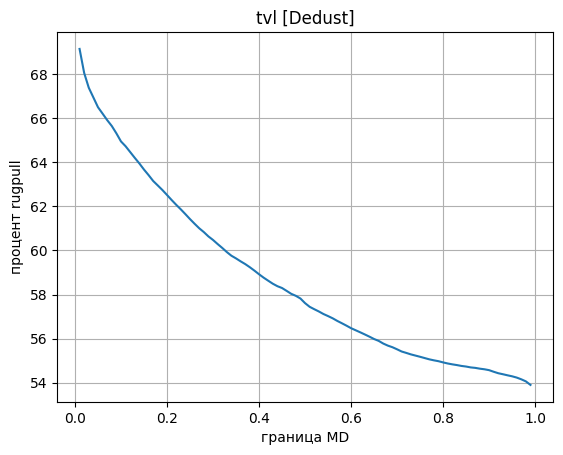

In [413]:
plt.plot([i/100 for i in range(1,100)], [(((dedust_df['max_tvl_60min'] - dedust_df['min_tvl_t_to_60min']) / dedust_df['max_tvl_60min'] > i / 100).astype(int)).mean()*100 for i in range(1,100)])
plt.grid()
plt.title('tvl [Dedust]')
plt.xlabel('граница MD')
plt.ylabel('процент rugpull')
plt.show()

In [414]:
# определяем таргет
# dedust_df['target'] = dedust_df['alice_rugpull_180min']
dedust_df['tvl_target_10min'] = ((dedust_df['max_tvl_10min'] -   dedust_df['min_tvl_t_to_10min']) / dedust_df['max_tvl_10min'] > 0.99).astype(int)
dedust_df['tvl_target_30min'] = ((dedust_df['max_tvl_30min'] -   dedust_df['min_tvl_t_to_30min']) / dedust_df['max_tvl_30min'] > 0.99).astype(int)
dedust_df['tvl_target_60min'] = ((dedust_df['max_tvl_60min'] -   dedust_df['min_tvl_t_to_60min']) / dedust_df['max_tvl_60min'] > 0.99).astype(int)
dedust_df['tvl_target_120min'] = ((dedust_df['max_tvl_120min'] - dedust_df['min_tvl_t_to_120min']) / dedust_df['max_tvl_120min'] > 0.99).astype(int)
dedust_df['tvl_target_180min'] = ((dedust_df['max_tvl_180min'] - dedust_df['min_tvl_t_to_180min']) / dedust_df['max_tvl_180min'] > 0.99).astype(int)
dedust_df['tvl_target_240min'] = ((dedust_df['max_tvl_240min'] - dedust_df['min_tvl_t_to_240min']) / dedust_df['max_tvl_240min'] > 0.99).astype(int)
dedust_df['tvl_target_300min'] = ((dedust_df['max_tvl_300min'] - dedust_df['min_tvl_t_to_300min']) / dedust_df['max_tvl_300min'] > 0.99).astype(int)
dedust_df['tvl_target_360min'] = ((dedust_df['max_tvl_360min'] - dedust_df['min_tvl_t_to_360min']) / dedust_df['max_tvl_360min'] > 0.99).astype(int)
dedust_df['tvl_target_420min'] = ((dedust_df['max_tvl_420min'] - dedust_df['min_tvl_t_to_420min']) / dedust_df['max_tvl_420min'] > 0.99).astype(int)
dedust_df = dedust_df.drop(['max_tvl_10min', 'max_tvl_30min', 'max_tvl_60min', 'max_tvl_120min', 'max_tvl_180min', 'max_tvl_240min', 'max_tvl_300min', 'max_tvl_360min', 'max_tvl_420min', 'min_tvl_t_to_10min', 'min_tvl_t_to_30min', 'min_tvl_t_to_60min', 'min_tvl_t_to_120min', 'min_tvl_t_to_180min', 'min_tvl_t_to_240min', 'min_tvl_t_to_300min', 'min_tvl_t_to_360min', 'min_tvl_t_to_420min'], axis=1) 
print(f"tvl_target_60min = {float(dedust_df['tvl_target_60min'].sum()/len(dedust_df)) * 100:.3}% rugpulls")
print(f'len of dedust_df: {len(dedust_df)}')

tvl_target_60min = 53.9% rugpulls
len of dedust_df: 32986


In [415]:
print(f"{'column_name':27}, {'example':66}, {'null percent'}")
for c, i in zip(dedust_df.columns, dedust_df.iloc[0]):
    print(f"{c:27}= {str(i):66}, {dedust_df[c].isna().mean()*100:.3}%")

column_name                , example                                                           , null percent
token_address              = 0:16590A541EF9DCBF226EAAD35BF7264B64F8DF0D8183931BE630192FB938E4C6, 0.0%
project                    = dedust                                                            , 0.0%
pool_address               = 0:DF28494AE0F7FB95B0135B483B8F035F0D2E31984B616CC633FA3C6466EA43A2, 0.0%
jetton_deployment_at       = 2024-04-19 06:08:58+00:00                                         , 0.0%
jetton_first_tx_sender     = 0:58E9F5E1E8A4A85F3C6C72062702274AAD5E66487E7BE34C0F16DD3AC76FE3AD, 0.0%
symbol                     = NOOB                                                              , 0.0546%
decimals                   = 9.0                                                               , 3.3%
buy_price_std_5min         = nan                                                               , 24.4%
buys_cnt                   = 3                                        

## Dataset prepare

In [426]:
dedust_df['first_trade_time'] = dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
dedust_df['count_tx_5min'] = dedust_df['buys_5min'] + dedust_df['sells_5min']
dedust_df['buy_perc_5min'] = dedust_df['buys_5min']/dedust_df['count_tx_5min']
dedust_df['sell_perc_5min'] = dedust_df['sells_5min']/dedust_df['count_tx_5min']
dedust_df['total_usd_volume_5min'] = dedust_df['total_usd_buy_volume_5min'] + dedust_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    dedust_df[f'{col}_month'] = pd.to_datetime(dedust_df[col]).dt.month
dedust_df['jetton_creation_year'] = pd.to_datetime(dedust_df['jetton_deployment_at']).dt.year
dedust_df['jetton_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['jetton_deployment_at']).dt.seconds
dedust_df['pool_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['pool_deployment_at']).dt.seconds
dedust_df['is_pool_creator'] = (dedust_df['pool_first_tx_sender'] == dedust_df['jetton_first_tx_sender']).astype(int)

dedust_df['buy_sell_ratio'] = dedust_df['buys_5min'] / (dedust_df['sells_5min'] + 1e-6)
dedust_df['price_range'] = dedust_df['price_max_5min'] - dedust_df['price_min_5min']
dedust_df['price_delta_5min'] = dedust_df['price_5min'] - dedust_df['initial_price']

## Correlation analysis

In [418]:
dedust_df['target'] = dedust_df['alice_rugpull_60min']

C:\Users\Димас\AppData\Local\Temp\ipykernel_21332\4283687199.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k-1, r-1))
C:\Users\Димас\AppData\Local\Temp\ipykernel_21332\4283687199.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


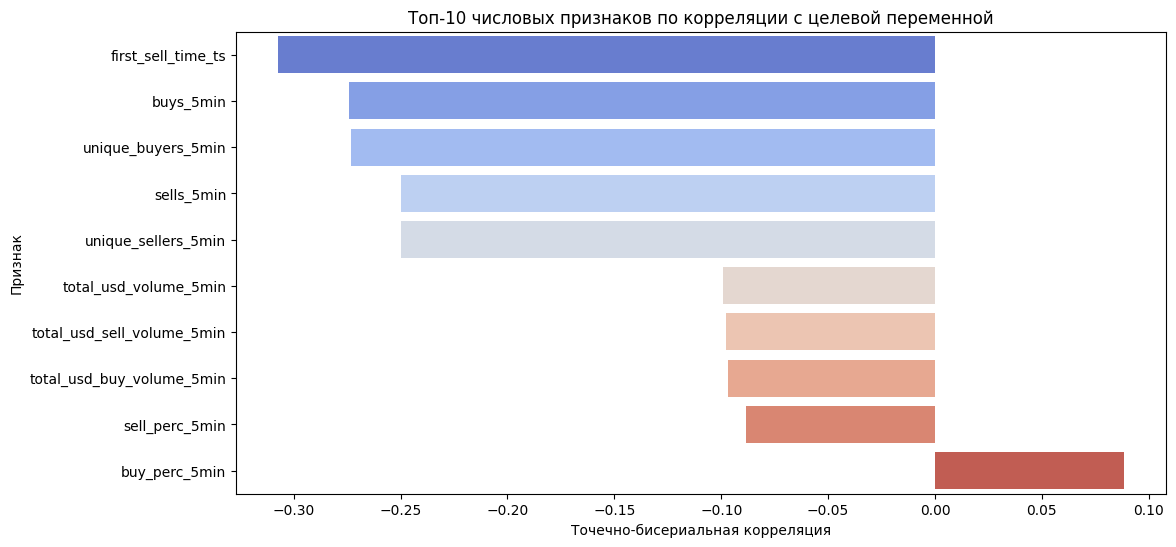

Топ числовых признаков:
                   feature  correlation      p-value
        first_sell_time_ts    -0.307145 0.000000e+00
                 buys_5min    -0.273927 0.000000e+00
        unique_buyers_5min    -0.273328 0.000000e+00
                sells_5min    -0.249997 0.000000e+00
       unique_sellers_5min    -0.249794 0.000000e+00
     total_usd_volume_5min    -0.098963 1.424926e-72
total_usd_sell_volume_5min    -0.097756 7.519309e-71
 total_usd_buy_volume_5min    -0.096955 1.017968e-69
            sell_perc_5min    -0.088354 3.654735e-58
             buy_perc_5min     0.088354 3.654735e-58

Топ категориальных признаков:
               feature  cramers_v
          pool_address   1.000000
         token_address   0.999952
jetton_first_tx_sender   0.880756
                symbol   0.783058
  pool_first_tx_sender   0.030873
               project        NaN


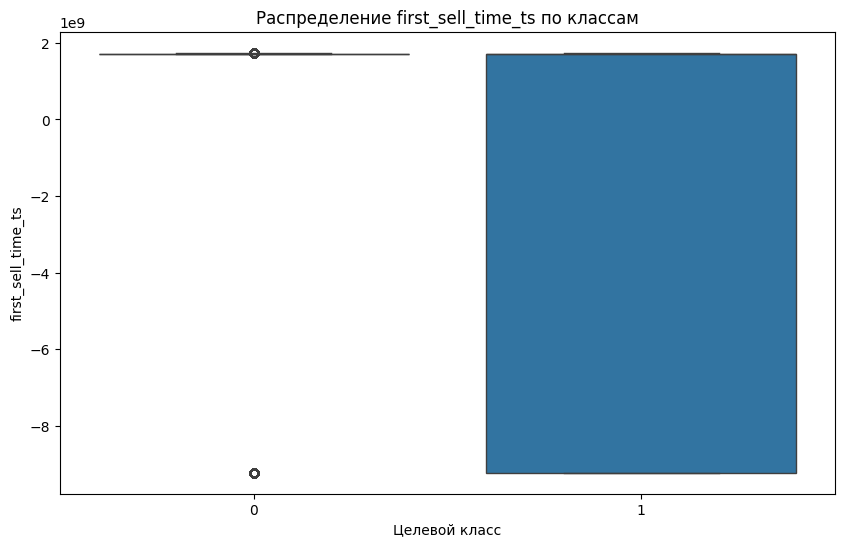

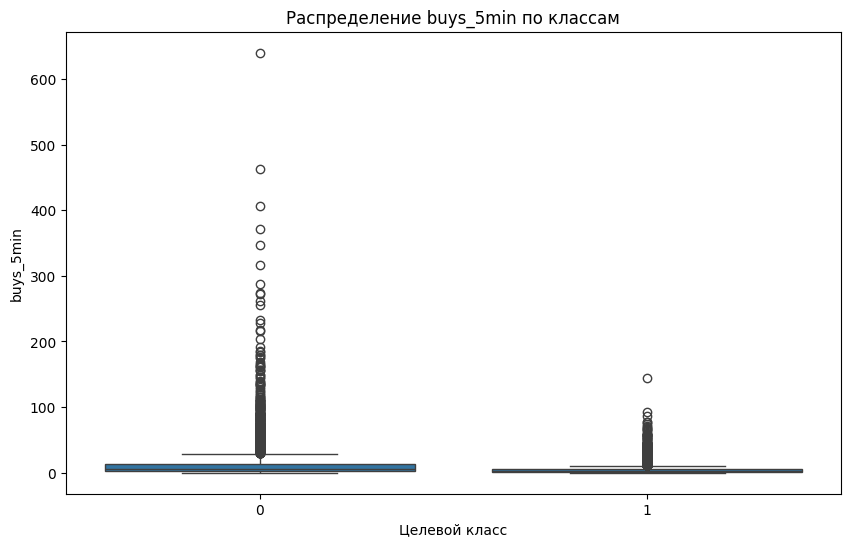

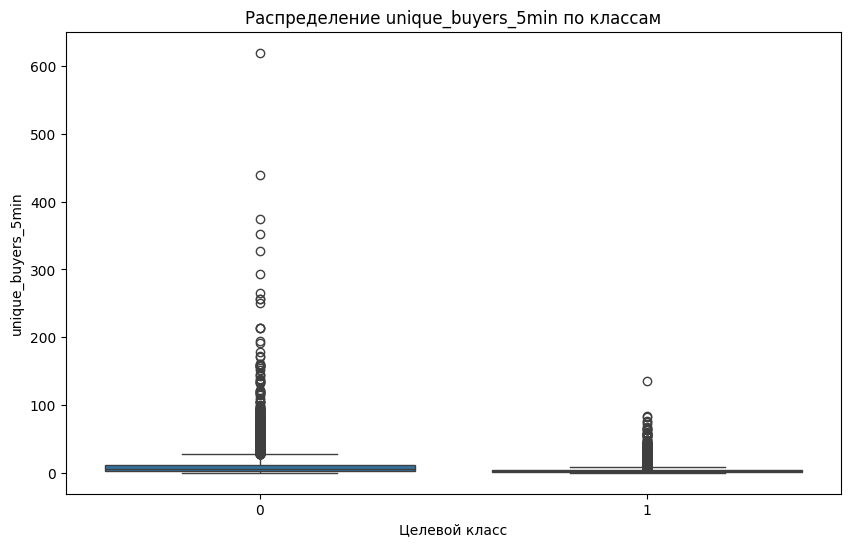

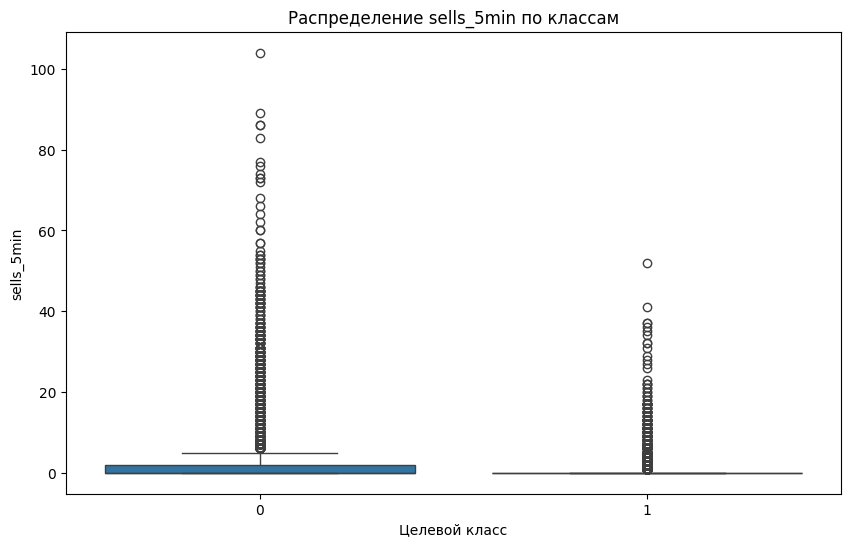

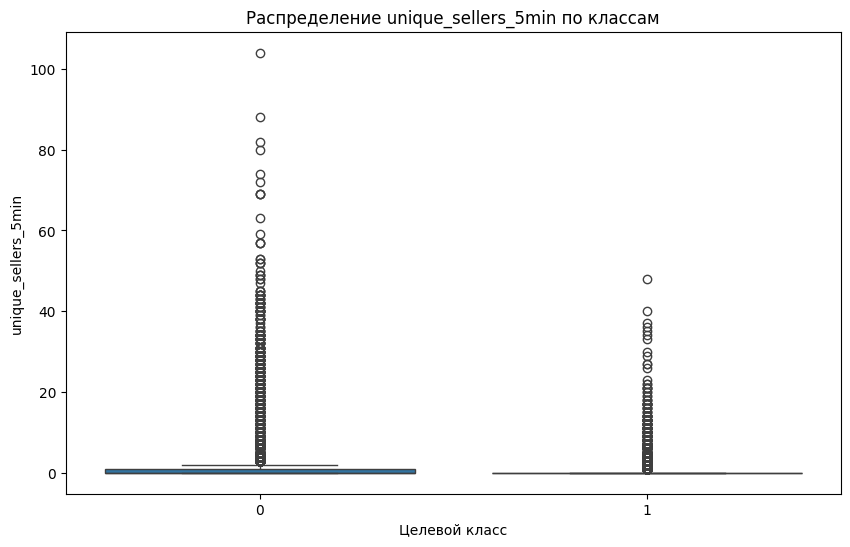

In [419]:

def cramers_v(x, y):
    """Вычисление корреляции Крамера для категориальных признаков"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Анализ для числовых признаков
numeric_features = dedust_df[numerical_features + cyclical_features].select_dtypes(include=np.number).columns.tolist()
# numeric_features.remove('target')  # Исключаем целевую переменную

numeric_correlations = []
for feature in numeric_features:
    r, p = pointbiserialr(dedust_df[feature], dedust_df['target'])
    numeric_correlations.append({
        'feature': feature,
        'correlation': r,
        'p-value': p
    })
    
numeric_corr_df = pd.DataFrame(numeric_correlations).sort_values(
    by='correlation', key=abs, ascending=False)

# Анализ для категориальных признаков
categorical_features = dedust_df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_correlations = []
for feature in categorical_features:
    v = cramers_v(dedust_df[feature], dedust_df['target'])
    categorical_correlations.append({
        'feature': feature,
        'cramers_v': v
    })
    
categorical_corr_df = pd.DataFrame(categorical_correlations).sort_values(
    by='cramers_v', ascending=False)

# Визуализация результатов
plt.figure(figsize=(12, 6))
sns.barplot(
    x='correlation', 
    y='feature', 
    data=numeric_corr_df.head(10),
    palette='coolwarm'
)
plt.title('Топ-10 числовых признаков по корреляции с целевой переменной')
plt.xlabel('Точечно-бисериальная корреляция')
plt.ylabel('Признак')
plt.show()

# Вывод результатов
print("Топ числовых признаков:")
print(numeric_corr_df.head(10).to_string(index=False))

print("\nТоп категориальных признаков:")
print(categorical_corr_df.head(10).to_string(index=False))

# Пример визуализации распределения для топ-признака
top_n = 5
for i in range(top_n):
    top_feature = numeric_corr_df.iloc[i]['feature']
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='target', y=top_feature, data=dedust_df)
    plt.title(f'Распределение {top_feature} по классам')
    plt.xlabel('Целевой класс')
    plt.ylabel(top_feature)
    plt.show()


# Learn

In [420]:

# Функции для циклического кодирования
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi), feature_names_out= lambda x, y: y)

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi), feature_names_out= lambda x, y: y)

## Data prepare

In [431]:
# Разделение данных

X = dedust_df[numerical_features + cyclical_features]
y = dedust_df['target']
# X = stonfi_df[numerical_features + cyclical_features]
# y = stonfi_df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [432]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('scaler', MaxAbsScaler())
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        # ('cat', categorical_transformer, categorical_features),
        ('cycl_sin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('sin', sin_transformer(12))
        ]), cyclical_features),
        ('cycl_cos', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('cos', cos_transformer(12))
        ]), cyclical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min',
                                  'jetto...
                                  'jetton_deployment_at_month']),
                                ('cycl_cos',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cos',
                                                  FunctionTransformer(feature_names_out=<function cos_transformer.<locals>.<lambda> at 0x000002332D1CF0A0>,
                                                                      func=<function cos_transformer.<locals>.<lambda> at 0x000002332D1CF130>))]),
                                 ['pool_deployment_at_month',
                                  'jetton_deployment_at_month'])])

### Data distribution

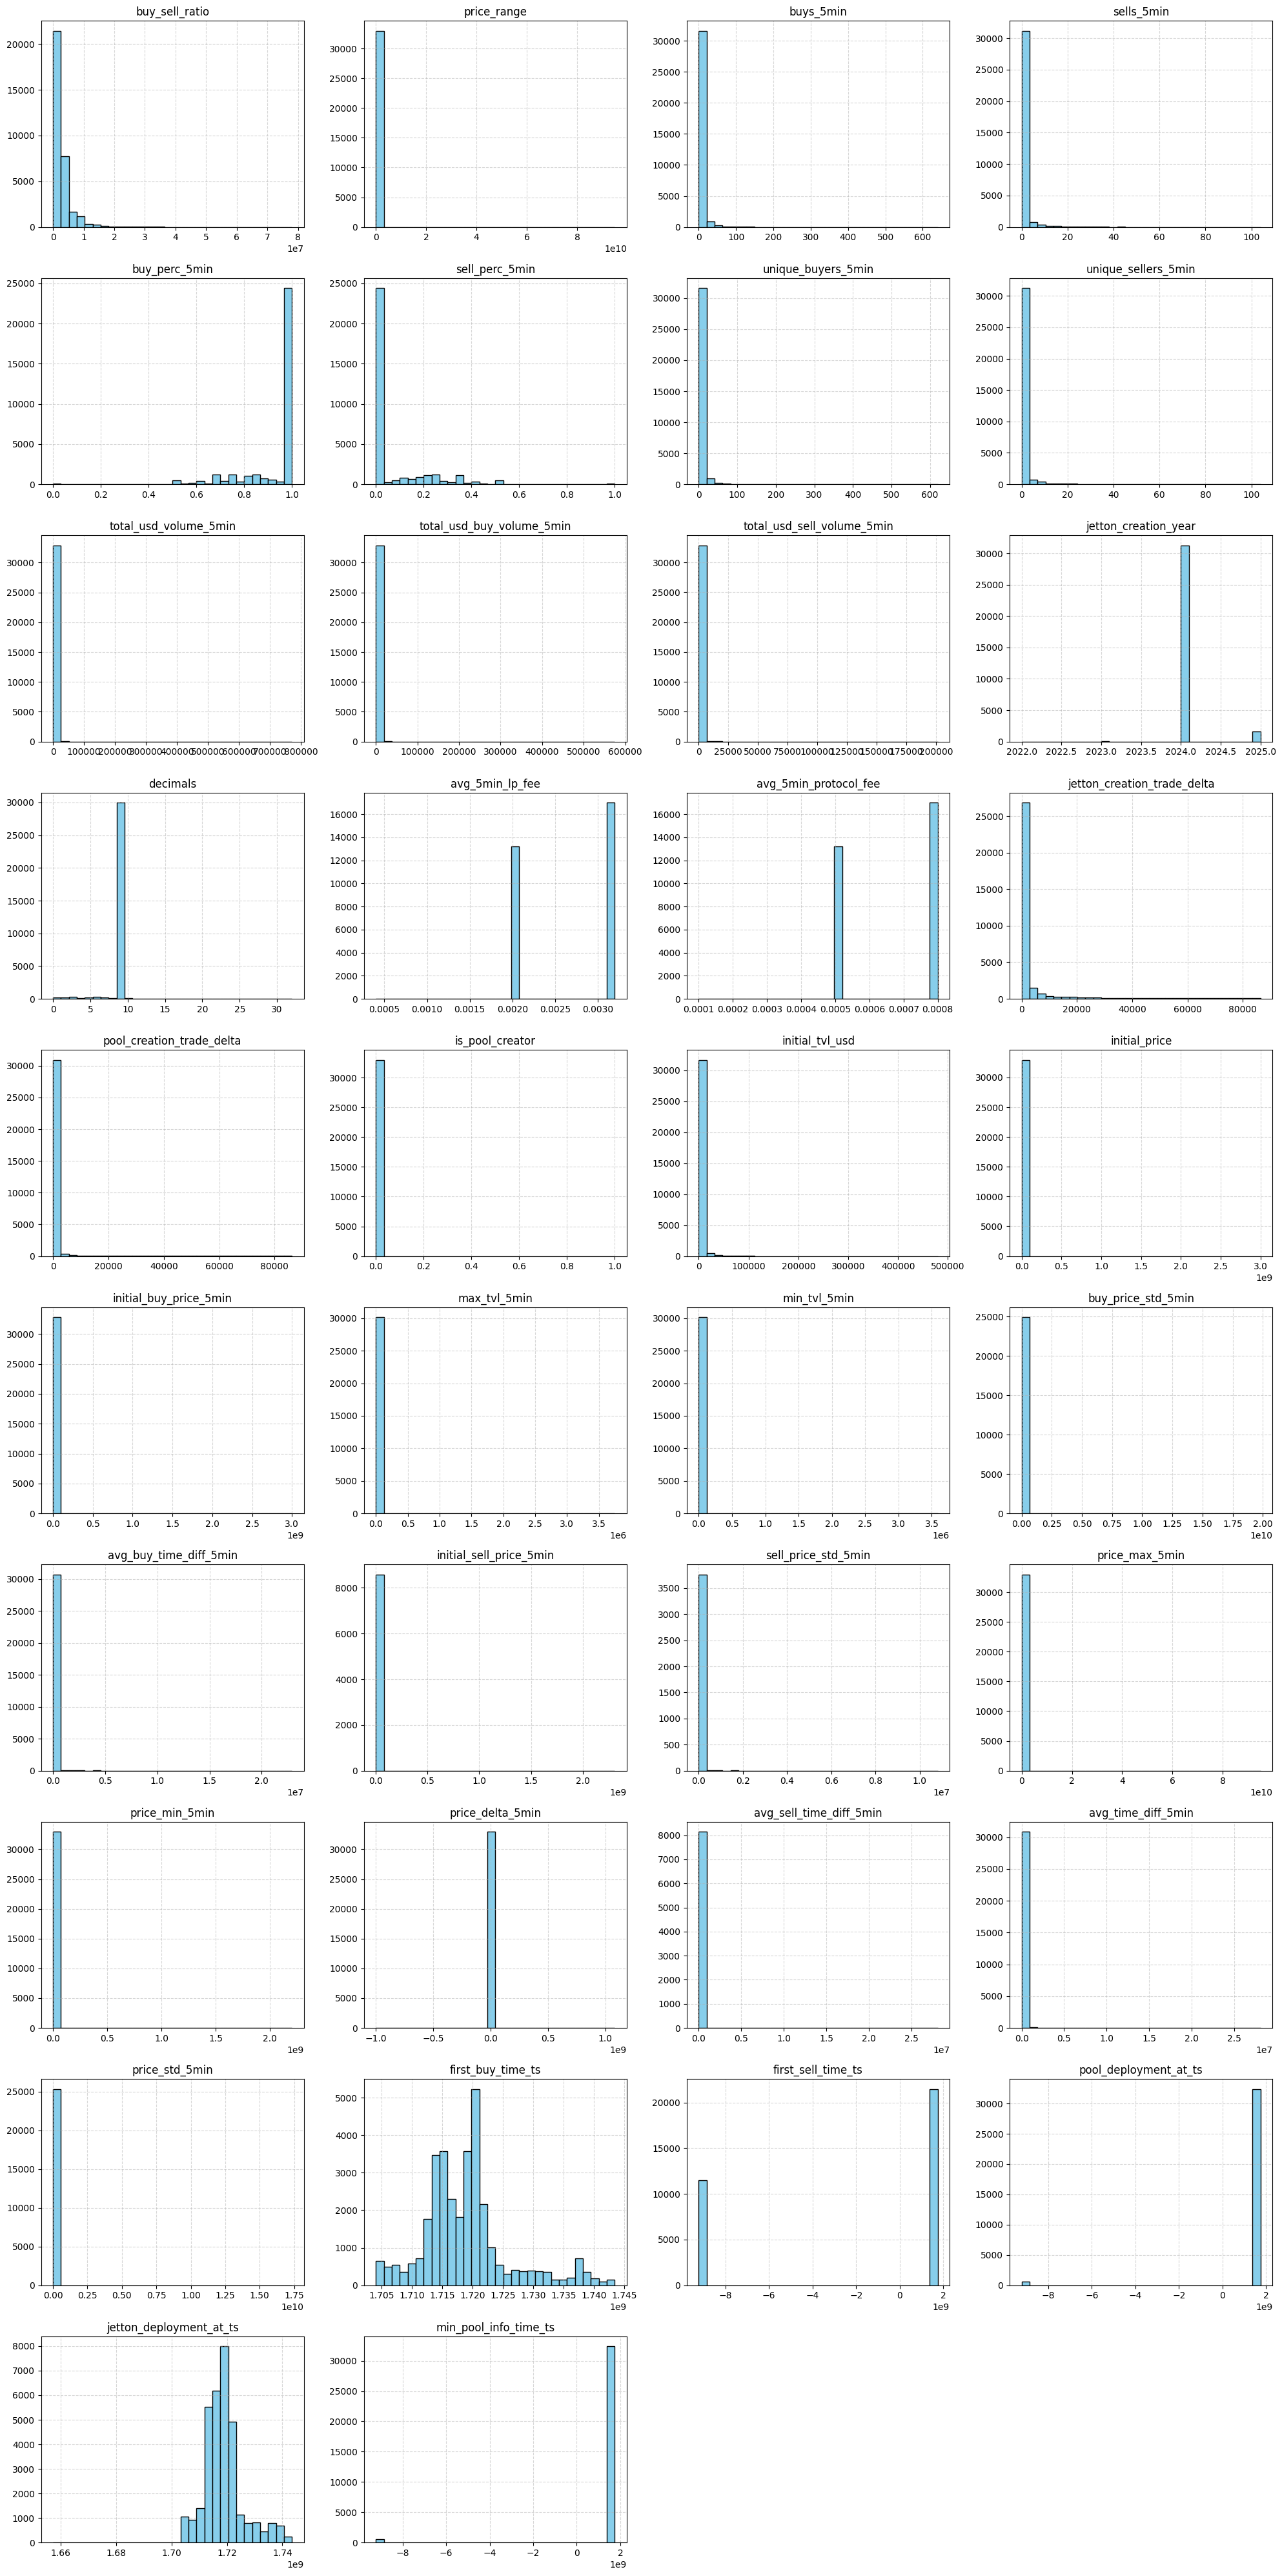

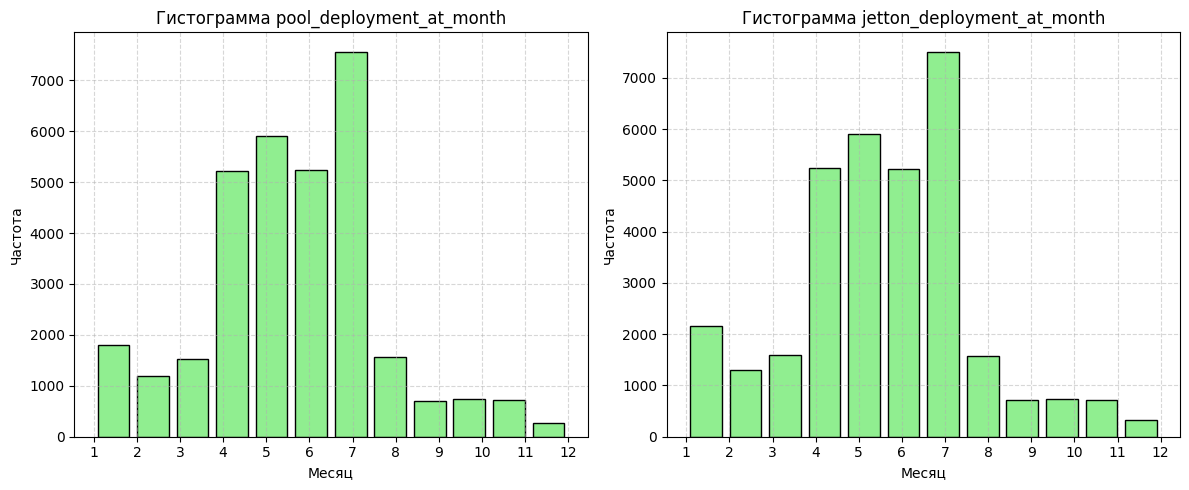

In [435]:
plot_features(X, numerical_features, cyclical_features)

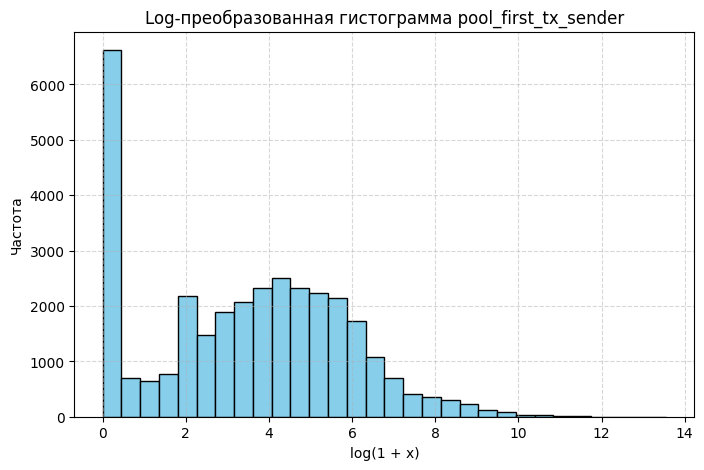

In [436]:
# # .apply(lambda x: np.log(x))
# X['total_usd_volume_5min'].hist(
#     bins=20,           # Количество корзин
#     figsize=(16, 12),  # Размер фигуры
#     grid=True,         # Сетка
#     edgecolor='black',  # Цвет границ столбцов

# )
# plt.tight_layout()
# plt.show()


plt.figure(figsize=(8, 5))
plt.hist(np.log1p(X['total_usd_volume_5min']), bins=30, color='skyblue', edgecolor='black')
plt.title(f'Log-преобразованная гистограмма {feature}')
plt.xlabel('log(1 + x)')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


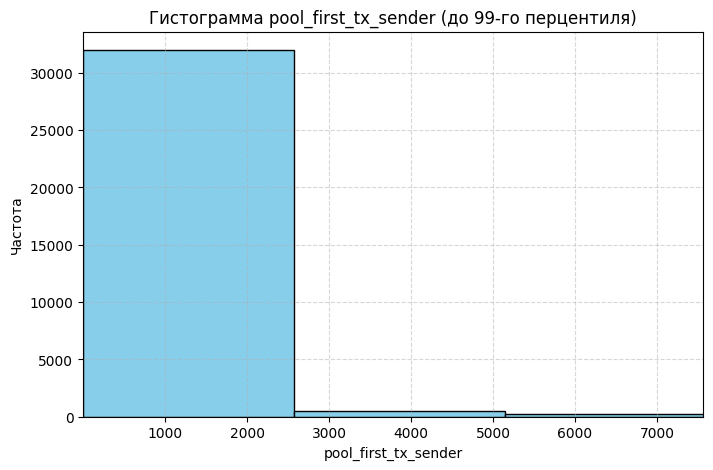

In [437]:
plt.figure(figsize=(8, 5))
plt.hist(X['total_usd_volume_5min'], bins=300, color='skyblue', edgecolor='black')
plt.xlim(X['total_usd_volume_5min'].quantile(0), X['total_usd_volume_5min'].quantile(0.99))  # только до 99-го перцентиля
plt.title(f'Гистограмма {feature} (до 99-го перцентиля)')
plt.xlabel(feature)
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [438]:
X_scaled = pd.DataFrame(
    preprocessor.fit_transform(X), 
    columns=all_features[:-2] + [i + '_sin' for i in all_features[-2:]] + [i + '_cos' for i in all_features[-2:]])
X_scaled.columns

Index(['buy_sell_ratio', 'price_range', 'buys_5min', 'sells_5min',
       'buy_perc_5min', 'sell_perc_5min', 'unique_buyers_5min',
       'unique_sellers_5min', 'total_usd_volume_5min',
       'total_usd_buy_volume_5min', 'total_usd_sell_volume_5min',
       'jetton_creation_year', 'decimals', 'avg_5min_lp_fee',
       'avg_5min_protocol_fee', 'jetton_creation_trade_delta',
       'pool_creation_trade_delta', 'is_pool_creator', 'initial_tvl_usd',
       'initial_price', 'initial_buy_price_5min', 'max_tvl_5min',
       'min_tvl_5min', 'buy_price_std_5min', 'avg_buy_time_diff_5min',
       'initial_sell_price_5min', 'sell_price_std_5min', 'price_max_5min',
       'price_min_5min', 'price_delta_5min', 'avg_sell_time_diff_5min',
       'avg_time_diff_5min', 'price_std_5min', 'first_buy_time_ts',
       'first_sell_time_ts', 'pool_deployment_at_ts',
       'jetton_deployment_at_ts', 'min_pool_info_time_ts',
       'pool_deployment_at_month_sin', 'jetton_deployment_at_month_sin',
       'poo

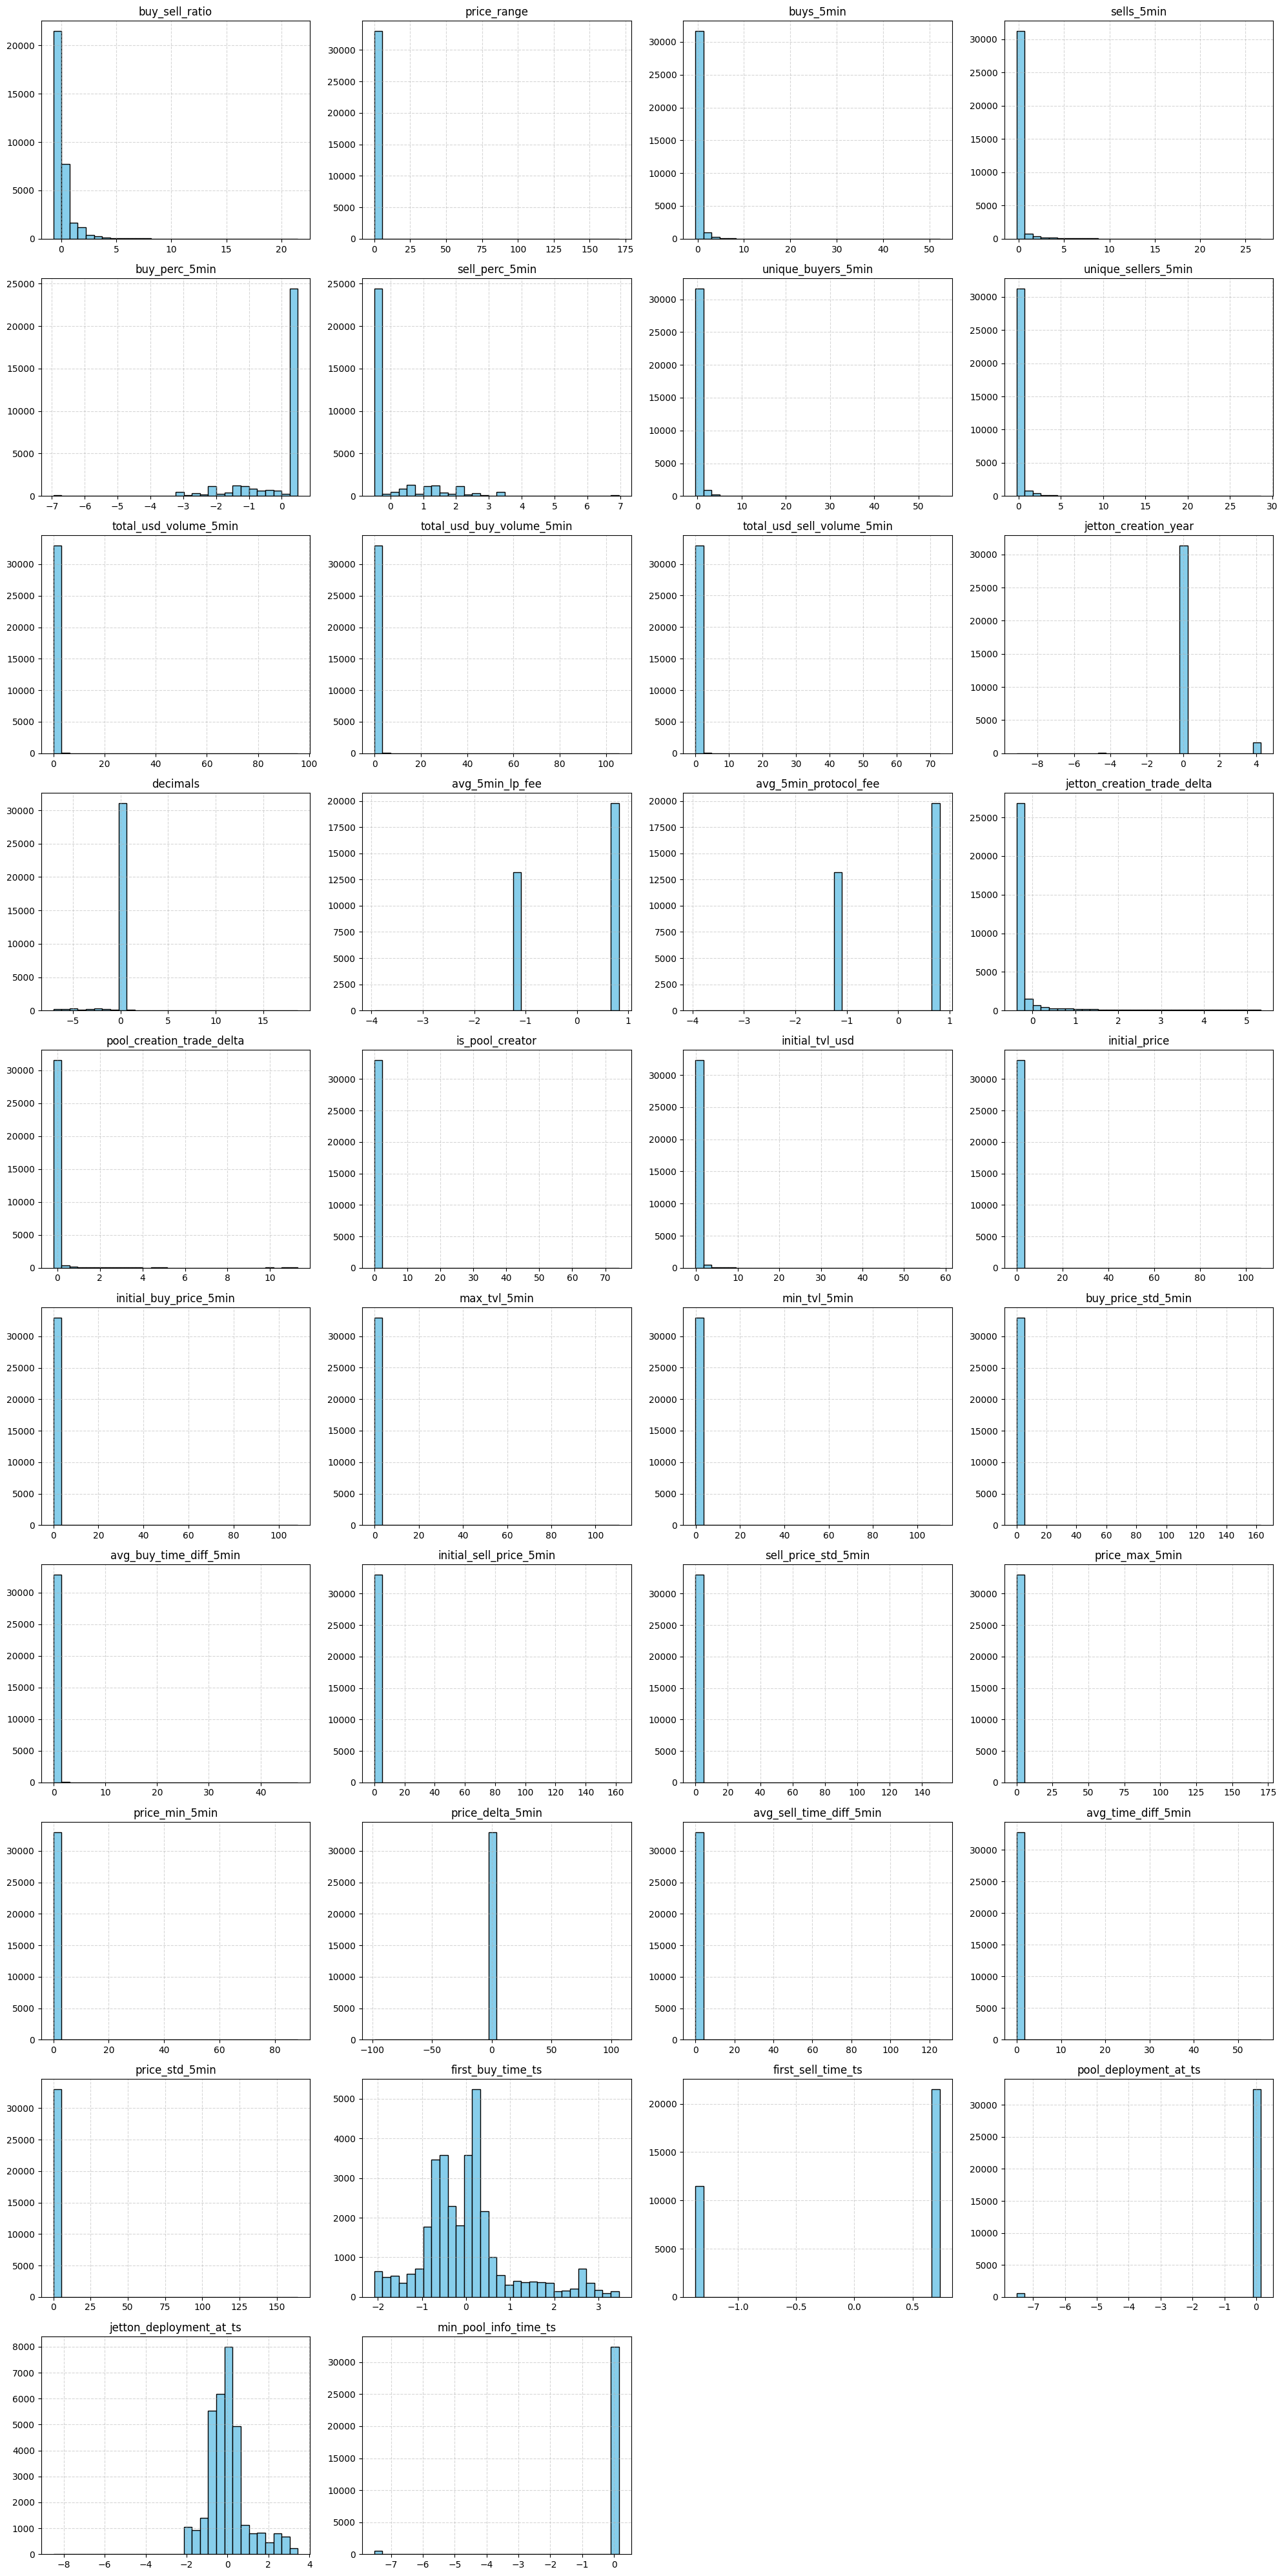

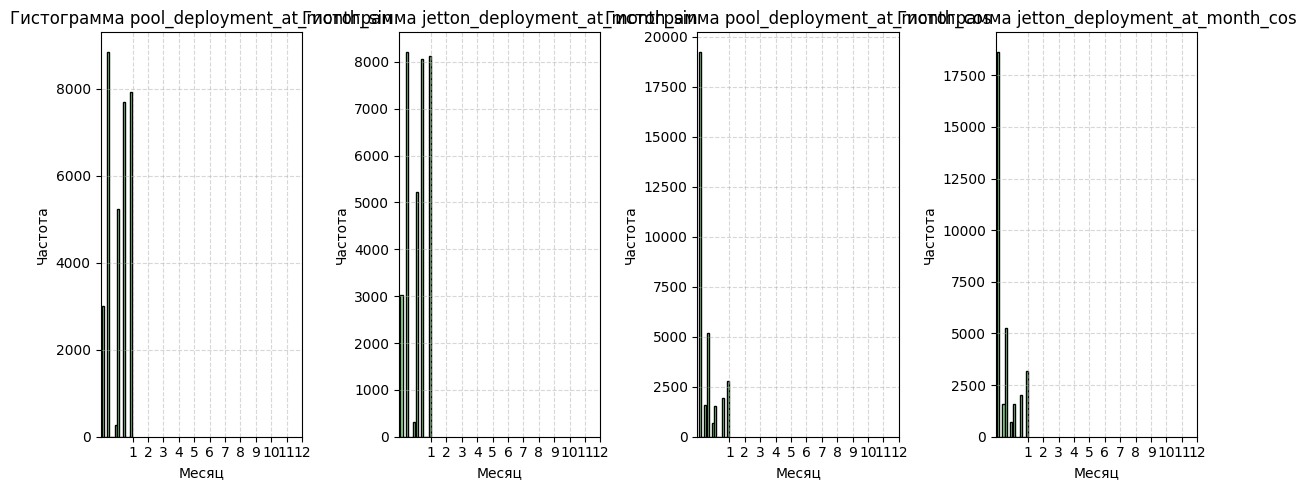

In [439]:
plot_features(
    X_scaled, 
    numerical_features, 
    [i + '_sin' for i in all_features[-2:]] + [i + '_cos' for i in all_features[-2:]]
)

## learn

In [440]:
# Настройка моделей и гиперпараметров
models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, bootstrap=True),
        'params': {
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [None, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            # 'classifier__bootstrap': [True, False],
            'classifier__class_weight': [{0: 0.3, 1: 0.7}, 'balanced']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            objective='binary:logistic', #
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5, 7, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1],
            'classifier__scale_pos_weight': [0.7/0.3, 0.83, 0.3/0.7]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5, 10],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__subsample': [0.8, 1.0],
            'classifier__loss': ['log_loss', 'exponential']
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.5, 1.0]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8]
        }
    },
    'ExtremeGradientBoosting': {
        'model': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            scale_pos_weight=0.82,
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [5, 7, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__reg_alpha': [0, 0.1, 1],
            'classifier__reg_lambda': [1, 1.5, 2]
        }
    }
}

# Обучение и оптимизация
results = {}
for model_name, config in models_config.items():
    print(f"Fit {model_name}")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

Fit RandomForest
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fit XGBoost
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Fit GradientBoosting
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Fit AdaBoost
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fit DecisionTree
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fit ExtremeGradientBoosting
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


## Анализ результатов

In [442]:

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

Model: RandomForest
Best CV AUC: 0.8578
Test AUC: 0.8615
Best Parameters:
  classifier__class_weight: balanced
  classifier__max_depth: None
  classifier__max_features: sqrt
  classifier__min_samples_split: 5
  classifier__n_estimators: 300
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1295
           1       0.86      0.95      0.91      5303

    accuracy                           0.84      6598
   macro avg       0.76      0.67      0.70      6598
weighted avg       0.82      0.84      0.82      6598



Model: XGBoost
Best CV AUC: 0.8624
Test AUC: 0.8659
Best Parameters:
  classifier__colsample_bytree: 1.0
  classifier__gamma: 0
  classifier__learning_rate: 0.1
  classifier__max_depth: 7
  classifier__scale_pos_weight: 0.4285714285714286
  classifier__subsample: 0.8
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58      1295
       

In [443]:
X.columns, X.shape

(Index(['buy_sell_ratio', 'price_range', 'buys_5min', 'sells_5min',
        'buy_perc_5min', 'sell_perc_5min', 'unique_buyers_5min',
        'unique_sellers_5min', 'total_usd_volume_5min',
        'total_usd_buy_volume_5min', 'total_usd_sell_volume_5min',
        'jetton_creation_year', 'decimals', 'avg_5min_lp_fee',
        'avg_5min_protocol_fee', 'jetton_creation_trade_delta',
        'pool_creation_trade_delta', 'is_pool_creator', 'initial_tvl_usd',
        'initial_price', 'initial_buy_price_5min', 'max_tvl_5min',
        'min_tvl_5min', 'buy_price_std_5min', 'avg_buy_time_diff_5min',
        'initial_sell_price_5min', 'sell_price_std_5min', 'price_max_5min',
        'price_min_5min', 'price_delta_5min', 'avg_sell_time_diff_5min',
        'avg_time_diff_5min', 'price_std_5min', 'first_buy_time_ts',
        'first_sell_time_ts', 'pool_deployment_at_ts',
        'jetton_deployment_at_ts', 'min_pool_info_time_ts',
        'pool_deployment_at_month', 'jetton_deployment_at_month'],
   

<Figure size 1000x600 with 0 Axes>

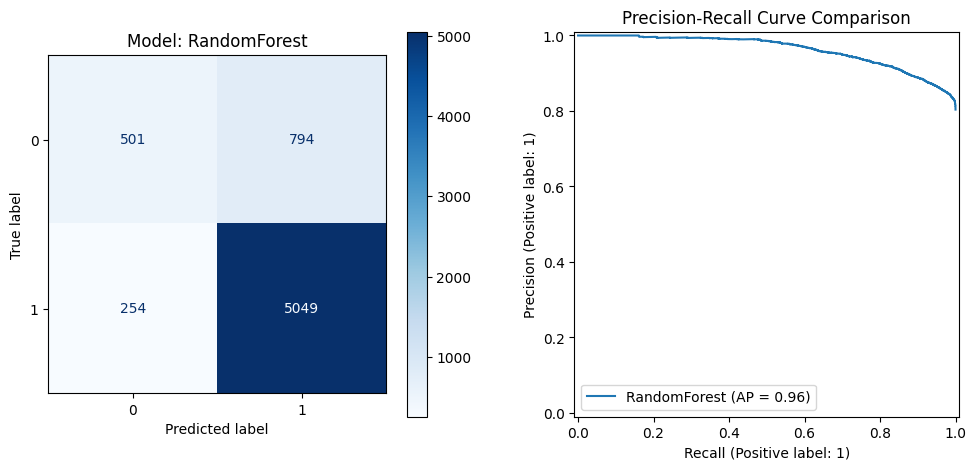

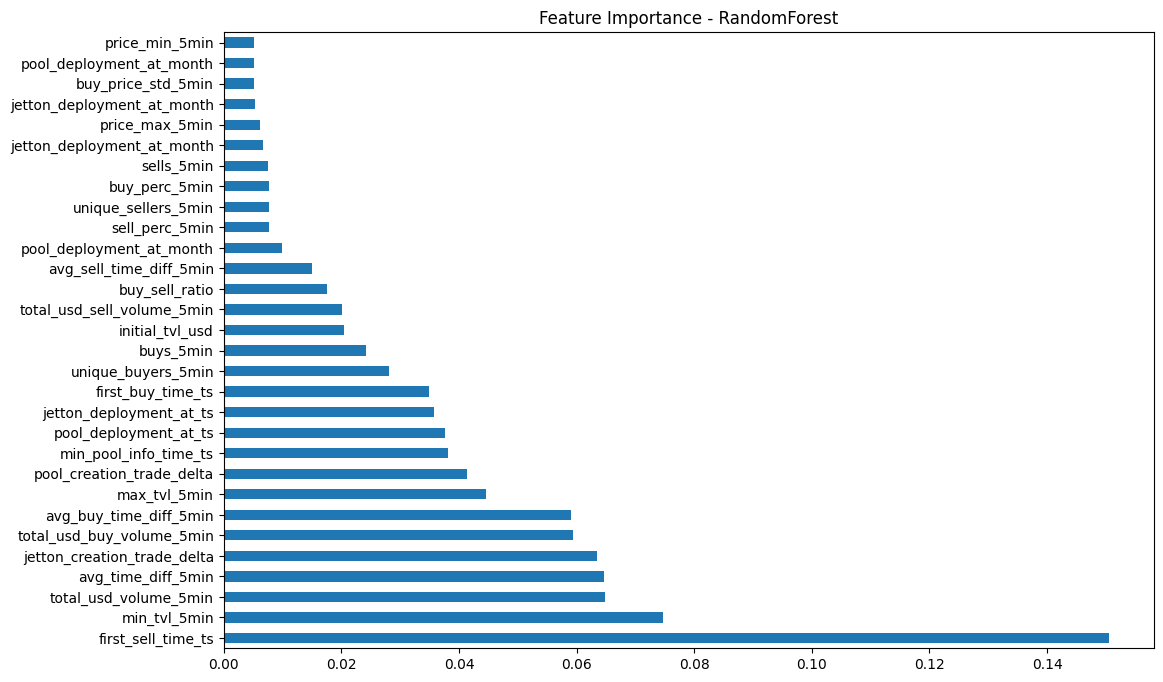

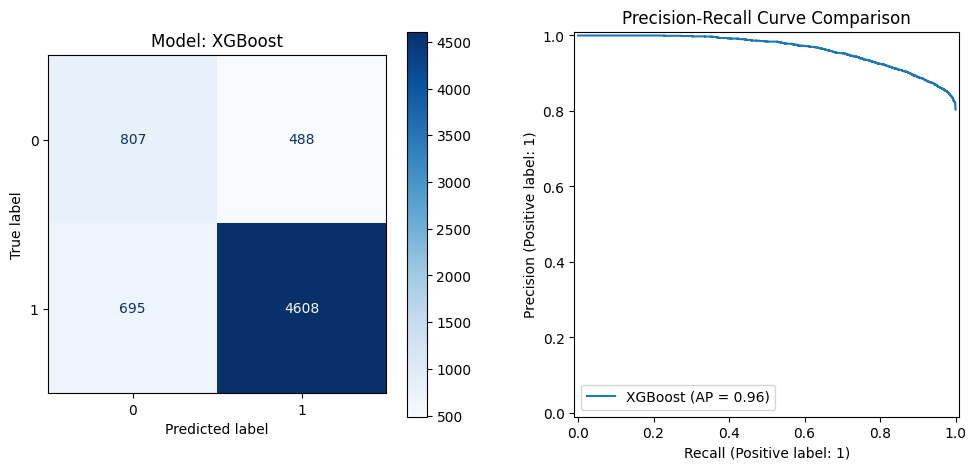

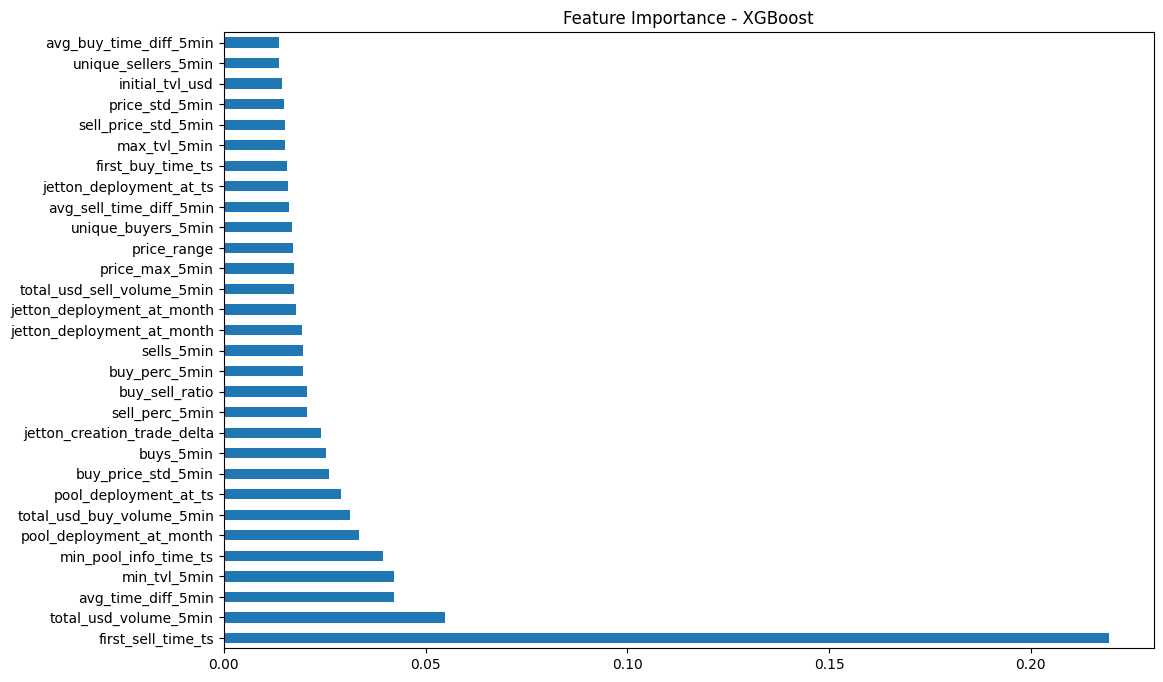

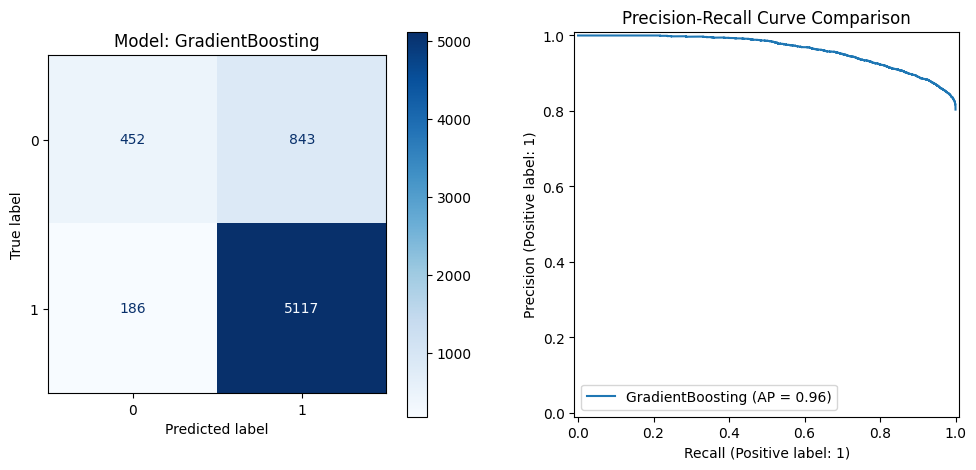

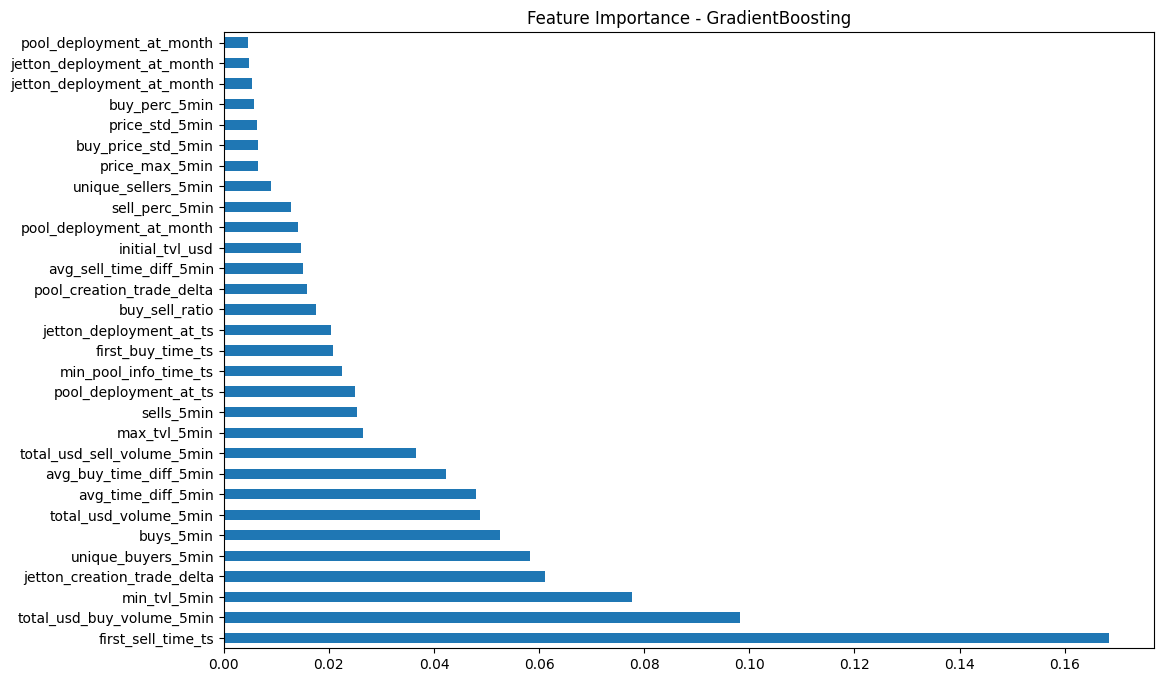

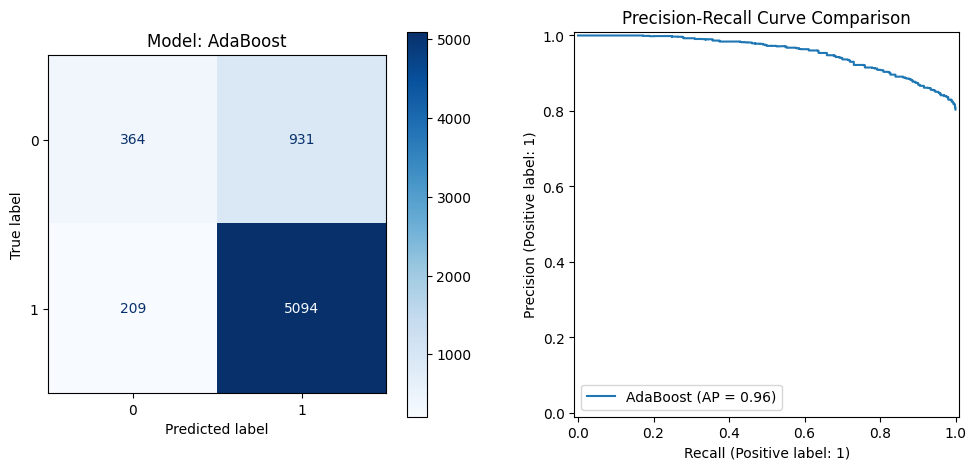

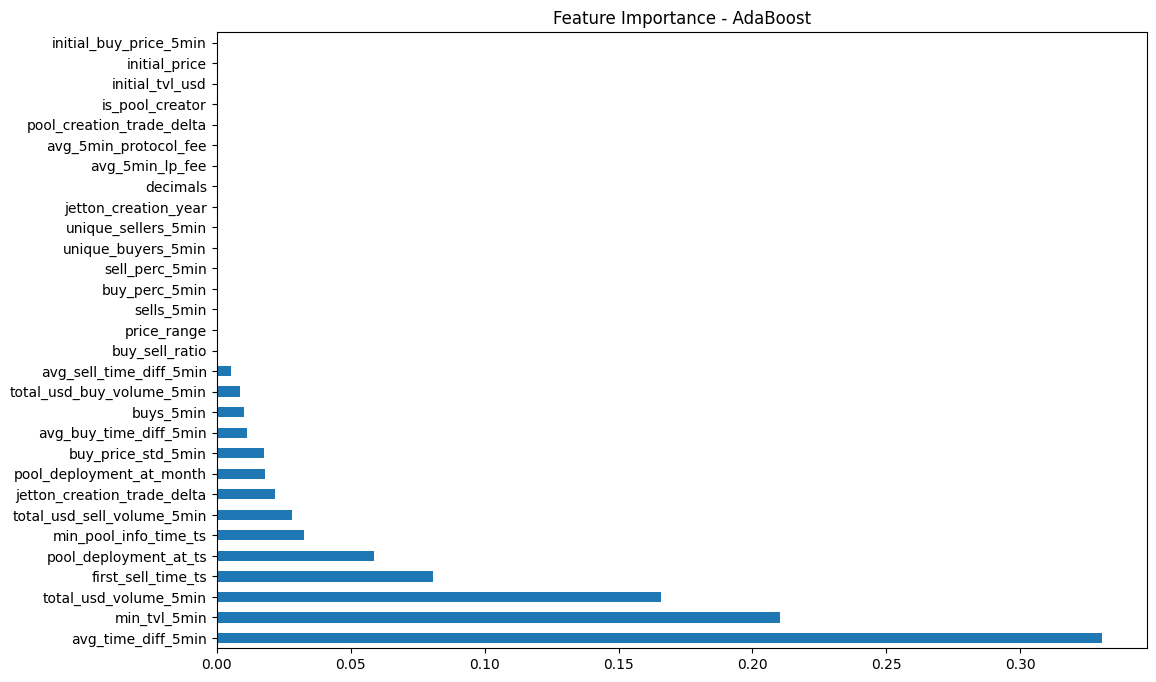

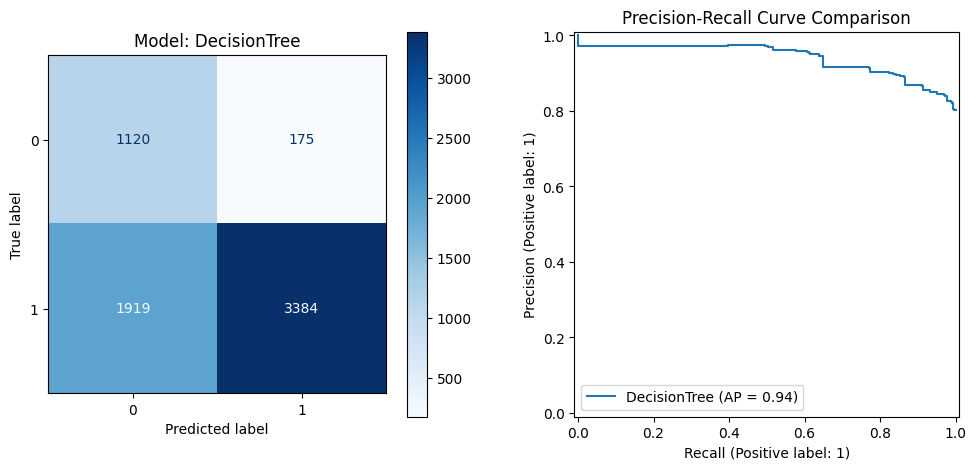

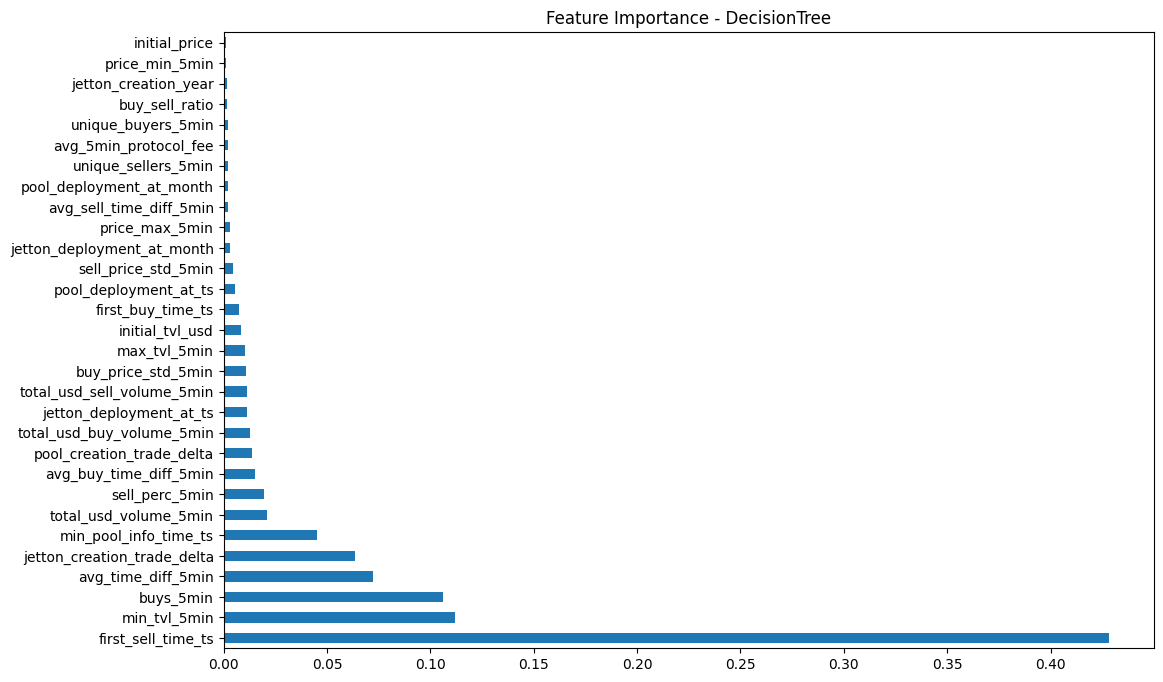

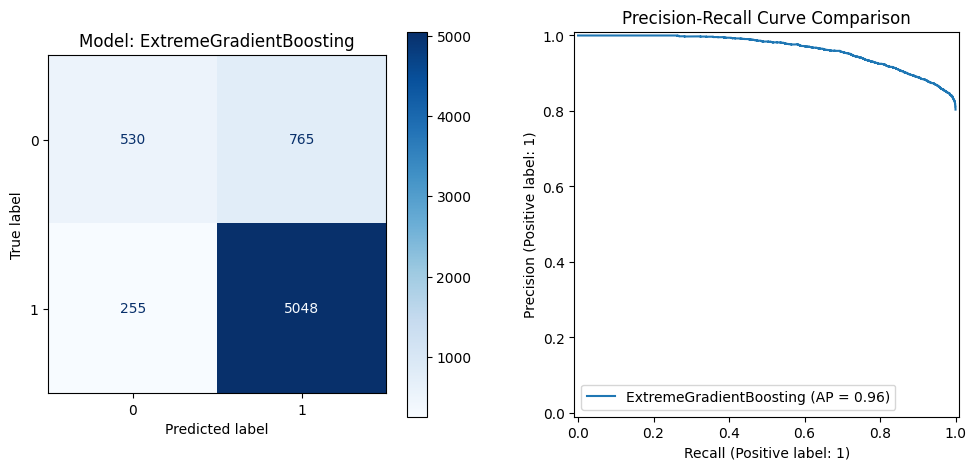

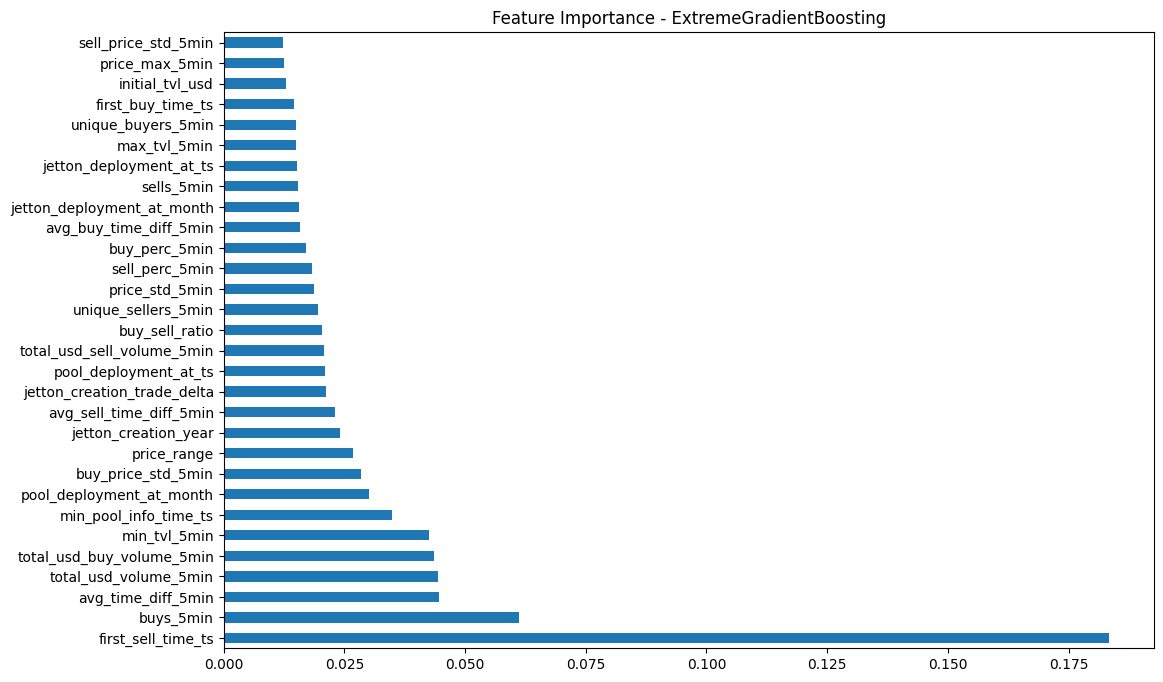

In [444]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # confusion_matrix
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f'Model: {name}')
    # График Precision Recall
    PrecisionRecallDisplay.from_estimator(
        res['model'], X_test, y_test, name=name, ax=ax2
    )
    ax2.set_title('Precision-Recall Curve Comparison')
    plt.show()

    # importances фичей
    importances = res['model'].named_steps['classifier'].feature_importances_
    # feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
    feature_names = numerical_features + cyclical_features + cyclical_features

    plt.figure(figsize=(12, 8))
    pd.Series(importances, index=feature_names).nlargest(30).plot(kind='barh')
    plt.title(f'Feature Importance - {name}')
    plt.show()


## preprocess

In [211]:
preprocessor.fit_transform(X).shape, X.shape

((32986, 41), (32986, 39))

In [218]:
pd.DataFrame(preprocessor.fit_transform(X.iloc[0:2]), columns=stonfi_df.columns.to_list() + ['sin', 'cos'])

c:\Users\Димас\venvs\main_venv\lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['initial_sell_price_5min' 'avg_sell_time_diff_5min']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


ValueError: Shape of passed values is (2, 39), indices imply (2, 96)

In [212]:
X.iloc[0:2]

,buy_sell_ratio,price_range,buys_5min,sells_5min,buy_perc_5min,sell_perc_5min,unique_buyers_5min,unique_sellers_5min,total_usd_volume_5min,total_usd_buy_volume_5min,...,avg_sell_time_diff_5min,avg_time_diff_5min,price_std,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts,pool_deployment_at_month,jetton_deployment_at_month
0,3000000.0,3.962398e-05,3,0,1.0,0.0,3,0,60.662800,60.662800,...,NaN,211.666667,2.415861e+02,1712921522,1712923189,1712919959,1710371985,1712919959,4.0,3
1,2000000.0,5.518260e-08,2,0,1.0,0.0,2,0,0.665393,0.665393,...,NaN,343.000000,4.689160e-08,1713625133,1713625819,1713624465,1713624061,1713625133,4.0,4


In [52]:
preprocessor

NameError: name 'preprocessor' is not defined

# Correlation

In [ ]:
stonfi_df[numerical_features + ['target']].corr()

,buy_sell_ratio,price_volatility,buys_5min,sells_5min,buy_perc_5min,sell_perc_5min,unique_buyers_5min,unique_sellers_5min,total_usd_volume_5min,total_usd_buy_volume_5min,...,initial_tvl_usd,initial_price,initial_buy_price_5min,max_tvl_5min,min_tvl_5min,initial_sell_price_5min,price_max_5min,price_min_5min,price_delta_5min,target
buy_sell_ratio,1.000000,-0.009924,0.028780,-0.103281,0.227187,-0.227187,0.026405,-0.102309,-0.035879,-0.019460,...,-0.015449,0.000129,0.000041,0.008017,0.030601,-0.007641,-0.009928,-0.006099,-0.003715,-0.021044
price_volatility,-0.009924,1.000000,-0.002436,-0.001869,-0.018710,0.018710,-0.002314,-0.001953,0.001324,0.002084,...,-0.001754,0.334479,0.334477,-0.001112,-0.001705,0.623567,1.000000,-0.000950,0.752121,0.004793
buys_5min,0.028780,-0.002436,1.000000,0.786223,-0.141633,0.141633,0.998417,0.779666,0.708746,0.593093,...,0.248451,-0.001344,-0.001386,0.085058,0.073356,-0.012374,-0.002440,-0.005969,-0.002066,-0.219577
sells_5min,-0.103281,-0.001869,0.786223,1.000000,-0.288788,0.288788,0.787899,0.990566,0.461058,0.353975,...,0.191120,-0.001640,-0.001659,0.037773,0.044372,-0.015029,-0.001872,-0.005748,-0.002758,-0.259882
buy_perc_5min,0.227187,-0.018710,-0.141633,-0.288788,1.000000,-1.000000,-0.144893,-0.281989,-0.089903,-0.055162,...,-0.064024,0.003271,0.003339,-0.009311,-0.018373,0.010253,-0.018717,-0.011158,-0.002461,0.137381
sell_perc_5min,-0.227187,0.018710,0.141633,0.288788,-1.000000,1.000000,0.144893,0.281989,0.089903,0.055162,...,0.064024,-0.003271,-0.003339,0.009311,0.018373,-0.010253,0.018717,0.011158,0.002461,-0.137381
unique_buyers_5min,0.026405,-0.002314,0.998417,0.787899,-0.144893,0.144893,1.000000,0.782672,0.707251,0.591784,...,0.244557,-0.001283,-0.001325,0.085507,0.074334,-0.012517,-0.002318,-0.006092,-0.002104,-0.219159
unique_sellers_5min,-0.102309,-0.001953,0.779666,0.990566,-0.281989,0.281989,0.782672,1.000000,0.458077,0.350621,...,0.195760,-0.001620,-0.001639,0.040322,0.047860,-0.014917,-0.001957,-0.005601,-0.002627,-0.255565
total_usd_volume_5min,-0.035879,0.001324,0.708746,0.461058,-0.089903,0.089903,0.707251,0.458077,1.000000,0.960117,...,0.273603,0.001548,0.001528,0.216971,0.158660,-0.006012,0.001322,-0.003185,0.000100,-0.140284
total_usd_buy_volume_5min,-0.019460,0.002084,0.593093,0.353975,-0.055162,0.055162,0.591784,0.350621,0.960117,1.000000,...,0.265656,0.002721,0.002705,0.231648,0.169056,-0.005052,0.002083,-0.002714,0.001029,-0.122272
